## 1) Estruturação das bases de todas as cervejas a partir do Excel

Neste bloco, foi criada uma rotina genérica para ler, limpar e padronizar as abas de cada cerveja do arquivo Excel, seguindo exatamente a mesma lógica aplicada anteriormente à base de **Malzbier**. O objetivo é transformar todas as abas relevantes em dataframes organizados e comparáveis no `pandas`, tanto para o **cenário atual** quanto para o **cenário com nova demanda**.

### O que o bloco faz

**1. Define o arquivo de origem**
- O código parte do arquivo `.xlsb` que contém as abas de cada cerveja.

**2. Cria uma função genérica de limpeza (`cleanup_cerveja`)**
- Essa função foi feita para reutilizar o mesmo tratamento em qualquer aba que siga o padrão do Excel.
- Ela:
  - lê a aba desejada
  - remove colunas auxiliares (`Unnamed`)
  - padroniza nomes de colunas
  - valida a existência da coluna `GEO/REG`
  - separa a semana 0
  - identifica automaticamente as semanas seguintes (`Demanda.1`, `Demanda.2`, etc.)
  - aceita tanto colunas `WSNP.n` quanto `Malha.n`
  - concatena tudo em formato longo
  - reconstrói o estoque inicial das semanas posteriores
  - calcula variáveis derivadas de estoque e cobertura

**3. Padroniza as métricas de cada semana**
Para cada aba, a base final passa a conter colunas padronizadas, como:
- `demanda_semana`
- `wsnp`
- `ei_semana`
- `suf_ini_d`
- `transf_interna`
- `transf_ext_cabo`
- `transf_ext_rodo`
- `transito`
- `ef_semana`
- `suf_f_d`

**4. Calcula variáveis analíticas relevantes**
Além das colunas originais, o bloco também cria métricas importantes para análise do case, como:
- `demanda_prox_semana`
- `ef_target_12`
- `gap_ef_12`
- `surplus_ef_12`
- `atende_doi_12`
- `status_doi_12`

Essas variáveis permitem avaliar se cada região atende ou não a meta de **DOI 12**, além de quantificar excesso ou falta de estoque.

**5. Processa múltiplas abas de uma vez**
- Foi criado um mapeamento com as abas:
  - cenário atual: abas com apenas o nome da cerveja
  - cenário novo: abas com sufixo `_Nova`
- Cada aba é processada automaticamente pela função genérica.

**6. Gera dataframes separados e uma base consolidada**
Ao final, o bloco:
- cria um dataframe individual para cada cerveja e cenário
- monta também uma base consolidada com todas as cervejas processadas

### Resultado esperado

Ao final da execução, todas as cervejas passam a estar disponíveis no `pandas` com a mesma estrutura de colunas e a mesma lógica de cálculo. Isso facilita:
- comparar cenário atual vs nova demanda
- construir gráficos padronizados
- aplicar regras de negócio iguais para diferentes SKUs
- consolidar análises em uma única base
- expandir a lógica desenvolvida para Malzbier para as demais cervejas

In [27]:
import pandas as pd
import numpy as np

# =========================================================
# CONFIGURAÇÃO DO ARQUIVO
# =========================================================
# Ajuste o caminho se necessário
arquivo = "Analise_LongNeck_WSNP - Rafael.xlsb"

# =========================================================
# FUNÇÃO GENÉRICA DE LIMPEZA / ESTRUTURAÇÃO
# =========================================================
def cleanup_cerveja(
    arquivo,
    sheet_name,
    sku_nome=None,
    mapa_semanas=None,
    engine="pyxlsb"
):
    """
    Lê uma aba de cerveja no formato do Excel do case e devolve
    um dataframe estruturado em formato longo, no mesmo padrão
    utilizado anteriormente para Malzbier.

    Parâmetros
    ----------
    arquivo : str
        Caminho do arquivo .xlsb
    sheet_name : str
        Nome da aba no Excel
    sku_nome : str ou None
        Nome padronizado do SKU. Se None, usa o nome da aba.
    mapa_semanas : dict ou None
        Mapeamento de semana_idx -> nome amigável da semana
    engine : str
        Engine do pandas para leitura

    Retorna
    -------
    pd.DataFrame
    """

    # =========================
    # 1) leitura
    # =========================
    raw = pd.read_excel(
        arquivo,
        sheet_name=sheet_name,
        engine=engine
    )

    # =========================
    # 2) limpeza inicial
    # =========================
    raw = raw.loc[
        :,
        ~pd.Index(raw.columns).astype(str).str.contains(r"^Unnamed", na=False)
    ].copy()

    raw.columns = [str(c).strip() for c in raw.columns]

    if "GEO/REG" not in raw.columns:
        raise ValueError(f"Coluna 'GEO/REG' não encontrada na aba '{sheet_name}'.")

    cols = raw.columns.tolist()

    # =========================
    # 3) semana 0
    # =========================
    bloco_w0_excel = [
        "Demanda",
        "WSNP",
        "EI Semana",
        "Suf.ini(d)",
        "Transf. Interna",
        "Transf. Ext (Cabo)",
        "Transf. Ext (Rodo)",
        "Trânsito",
        "EF Semana",
        "Suf. f (d)"
    ]

    faltantes_w0 = [c for c in bloco_w0_excel if c not in cols]
    if faltantes_w0:
        raise ValueError(
            f"Faltam colunas esperadas da semana 0 na aba '{sheet_name}': {faltantes_w0}"
        )

    sem0 = raw[["GEO/REG"] + bloco_w0_excel].copy()
    sem0.columns = [
        "geo_reg",
        "demanda_semana",
        "wsnp",
        "ei_semana",
        "suf_ini_d",
        "transf_interna",
        "transf_ext_cabo",
        "transf_ext_rodo",
        "transito",
        "ef_semana",
        "suf_f_d"
    ]
    sem0["semana_idx"] = 0

    dfs_semanais = [sem0]

    # =========================
    # 4) auxiliar
    # =========================
    def pega_coluna(df, candidatos, default=0.0):
        for c in candidatos:
            if c in df.columns:
                return df[c]
        return pd.Series([default] * len(df), index=df.index)

    # =========================
    # 5) semanas seguintes
    # =========================
    idxs_demanda_n = [
        i for i, c in enumerate(cols)
        if str(c).startswith("Demanda.")
    ]

    for idx in idxs_demanda_n:
        col_dem = cols[idx]
        sufixo = col_dem.split(".", 1)[1]

        df_sem = pd.DataFrame(index=raw.index)
        df_sem["geo_reg"] = raw["GEO/REG"]

        df_sem["demanda_semana"] = pega_coluna(
            raw,
            [f"Demanda.{sufixo}"],
            default=np.nan
        )

        # aceita WSNP.n ou Malha.n
        df_sem["wsnp"] = pega_coluna(
            raw,
            [f"WSNP.{sufixo}", f"Malha.{sufixo}"],
            default=0.0
        )

        df_sem["ei_semana"] = np.nan
        df_sem["suf_ini_d"] = np.nan

        df_sem["transf_interna"] = pega_coluna(
            raw,
            [f"Transf. Interna.{sufixo}"],
            default=0.0
        )

        df_sem["transf_ext_cabo"] = pega_coluna(
            raw,
            [f"Transf. Ext (Cabo).{sufixo}"],
            default=0.0
        )

        df_sem["transf_ext_rodo"] = pega_coluna(
            raw,
            [f"Transf. Ext (Rodo).{sufixo}"],
            default=0.0
        )

        df_sem["transito"] = pega_coluna(
            raw,
            [f"Trânsito.{sufixo}"],
            default=0.0
        )

        df_sem["ef_semana"] = pega_coluna(
            raw,
            [f"EF Semana.{sufixo}"],
            default=np.nan
        )

        df_sem["suf_f_d"] = pega_coluna(
            raw,
            [f"Suf. f (d).{sufixo}"],
            default=np.nan
        )

        df_sem["semana_idx"] = int(sufixo)
        dfs_semanais.append(df_sem)

    # =========================
    # 6) concatena em formato longo
    # =========================
    df = pd.concat(dfs_semanais, ignore_index=True)

    # =========================
    # 7) ordena e reconstrói EI
    # =========================
    df = df.sort_values(["geo_reg", "semana_idx"]).reset_index(drop=True)

    mask_semana_maior_0 = df["semana_idx"] > 0
    df.loc[mask_semana_maior_0, "ei_semana"] = (
        df.groupby("geo_reg")["ef_semana"].shift(1)
    )

    df["suf_ini_d"] = np.where(
        df["demanda_semana"].notna() & (df["demanda_semana"] != 0),
        df["ei_semana"] / (df["demanda_semana"] / 6),
        np.nan
    )

    # =========================
    # 8) demanda da próxima semana
    # =========================
    df["demanda_prox_semana"] = (
        df.groupby("geo_reg")["demanda_semana"].shift(-1)
    )

    # =========================
    # 9) nomes das semanas
    # =========================
    if mapa_semanas is None:
        mapa_semanas = {
            0: "W0_02_02_2026",
            1: "W1_09_02_2026",
            2: "W2_16_02_2026",
            3: "W3_23_02_2026"
        }

    df["semana"] = df["semana_idx"].map(mapa_semanas)
    df["sku"] = sku_nome if sku_nome is not None else sheet_name

    # =========================
    # 10) variáveis derivadas
    # =========================
    df["ajuste_cabo"] = df["transf_ext_cabo"].where(
        df["transf_ext_cabo"] < 0, 0
    )

    df["ef_semana"] = (
        df["ei_semana"]
        + df["wsnp"]
        - df["demanda_semana"]
        + df["transf_interna"]
        + df["transf_ext_rodo"]
        + df["transito"]
        + df["ajuste_cabo"]
    )

    df["suf_f_d"] = np.where(
        df["demanda_prox_semana"].notna() & (df["demanda_prox_semana"] != 0),
        df["ef_semana"] / (df["demanda_prox_semana"] / 6),
        np.nan
    )

    df["ef_target_12"] = np.where(
        df["demanda_prox_semana"].notna(),
        2 * df["demanda_prox_semana"],
        np.nan
    )

    df["gap_ef_12"] = (
        df["ef_target_12"] - df["ef_semana"]
    ).clip(lower=0)

    df["surplus_ef_12"] = (
        df["ef_semana"] - df["ef_target_12"]
    ).clip(lower=0)

    df["atende_doi_12"] = df["suf_f_d"] >= (12 - 1e-6)
    df["status_doi_12"] = df["atende_doi_12"].map({
        True: "Atende",
        False: "Não atende"
    })

    # =========================
    # 11) organiza colunas finais
    # =========================
    colunas_finais = [
        "sku",
        "semana",
        "semana_idx",
        "geo_reg",
        "demanda_semana",
        "demanda_prox_semana",
        "wsnp",
        "ei_semana",
        "suf_ini_d",
        "transf_interna",
        "transf_ext_cabo",
        "transf_ext_rodo",
        "transito",
        "ajuste_cabo",
        "ef_semana",
        "suf_f_d",
        "ef_target_12",
        "gap_ef_12",
        "surplus_ef_12",
        "atende_doi_12",
        "status_doi_12"
    ]

    df = df[colunas_finais]
    return df


# =========================================================
# MAPEAMENTO DAS ABAS
# =========================================================
# Ajuste os nomes dos SKUs se quiser deixá-los padronizados
mapa_abas = {
    "Patagonia": "PATAGONIA",
    "Patagonia_Nova": "PATAGONIA_NOVA",
    "Goose": "GOOSE",
    "Goose_Nova": "GOOSE_NOVA",
    "Malzbier": "MALZBIER BRAHMA LN355ML SIX PAC BAND C/4",
    "Malzbier_Nova": "MALZBIER BRAHMA LN355ML SIX PAC BAND C/4_NOVA",
    "Colorado": "COLORADO",
    "Colorado_Nova": "COLORADO_NOVA",
}

# =========================================================
# PROCESSA TODAS AS ABAS
# =========================================================
bases_cervejas = {}

for aba, sku_nome in mapa_abas.items():
    try:
        bases_cervejas[aba] = cleanup_cerveja(
            arquivo=arquivo,
            sheet_name=aba,
            sku_nome=sku_nome
        )
        print(f"OK - aba processada: {aba}")
    except Exception as e:
        print(f"ERRO - aba '{aba}': {e}")

# =========================================================
# DATAFRAMES INDIVIDUAIS
# =========================================================
patagonia_atual = bases_cervejas.get("Patagonia")
patagonia_nova = bases_cervejas.get("Patagonia_Nova")

goose_atual = bases_cervejas.get("Goose")
goose_nova = bases_cervejas.get("Goose_Nova")

malzbier_atual = bases_cervejas.get("Malzbier")
malzbier_nova = bases_cervejas.get("Malzbier_Nova")

colorado_atual = bases_cervejas.get("Colorado")
colorado_nova = bases_cervejas.get("Colorado_Nova")

# =========================================================
# BASE CONSOLIDADA
# =========================================================
bases_validas = [df for df in bases_cervejas.values() if df is not None]
base_consolidada_cervejas = pd.concat(bases_validas, ignore_index=True) if bases_validas else pd.DataFrame()

# =========================================================
# EXIBIÇÃO
# =========================================================
print("\n--- Exemplo: Malzbier atual ---")
if malzbier_atual is not None:
    display(malzbier_atual.head(5))

print("\n--- Exemplo: Malzbier nova demanda ---")
if malzbier_nova is not None:
    display(malzbier_nova.head(5))

print("\n--- Base consolidada de todas as cervejas ---")
display(base_consolidada_cervejas.head(5)) 

OK - aba processada: Patagonia
OK - aba processada: Patagonia_Nova
OK - aba processada: Goose
OK - aba processada: Goose_Nova
OK - aba processada: Malzbier
OK - aba processada: Malzbier_Nova
OK - aba processada: Colorado
OK - aba processada: Colorado_Nova

--- Exemplo: Malzbier atual ---


,sku,semana,semana_idx,geo_reg,demanda_semana,demanda_prox_semana,wsnp,ei_semana,suf_ini_d,transf_interna,...,transf_ext_rodo,transito,ajuste_cabo,ef_semana,suf_f_d,ef_target_12,gap_ef_12,surplus_ef_12,atende_doi_12,status_doi_12
0,MALZBIER BRAHMA LN355ML SIX PAC BAND C/4,W0_02_02_2026,0,Mapapi,4672.926,4835.700,0,1985.61600,2.549515,5050.04832,...,0,0,0,2362.73832,2.931619,9671.400,7308.66168,0.00000,False,Não atende
1,MALZBIER BRAHMA LN355ML SIX PAC BAND C/4,W1_09_02_2026,1,Mapapi,4835.700,3275.406,0,2362.73832,2.931619,6161.58468,...,0,0,0,3688.62300,6.756945,6550.812,2862.18900,0.00000,False,Não atende
2,MALZBIER BRAHMA LN355ML SIX PAC BAND C/4,W2_16_02_2026,2,Mapapi,3275.406,4003.524,0,3688.62300,6.756945,2792.98818,...,0,0,0,3206.20518,4.805074,8007.048,4800.84282,0.00000,False,Não atende
3,MALZBIER BRAHMA LN355ML SIX PAC BAND C/4,W3_23_02_2026,3,Mapapi,4003.524,NaN,0,3206.20518,4.805074,3048.11046,...,0,0,0,2250.79164,NaN,NaN,NaN,NaN,False,Não atende
4,MALZBIER BRAHMA LN355ML SIX PAC BAND C/4,W0_02_02_2026,0,NE Norte,1516.734,1742.922,16200,302.00400,1.194688,-9281.16846,...,0,0,0,5704.10154,19.636340,3485.844,0.00000,2218.25754,True,Atende



--- Exemplo: Malzbier nova demanda ---


,sku,semana,semana_idx,geo_reg,demanda_semana,demanda_prox_semana,wsnp,ei_semana,suf_ini_d,transf_interna,...,transf_ext_rodo,transito,ajuste_cabo,ef_semana,suf_f_d,ef_target_12,gap_ef_12,surplus_ef_12,atende_doi_12,status_doi_12
0,MALZBIER BRAHMA LN355ML SIX PAC BAND C/4_NOVA,W0_02_02_2026,0,Mapapi,6074.8038,6286.4100,0,1985.61600,1.961166,5050.04832,...,0,0,0,960.86052,0.917084,12572.8200,11611.95948,0.00000,False,Não atende
1,MALZBIER BRAHMA LN355ML SIX PAC BAND C/4_NOVA,W1_09_02_2026,1,Mapapi,6286.4100,4258.0278,0,960.86052,0.917084,6161.58468,...,0,0,0,836.03520,1.178060,8516.0556,7680.02040,0.00000,False,Não atende
2,MALZBIER BRAHMA LN355ML SIX PAC BAND C/4_NOVA,W2_16_02_2026,2,Mapapi,4258.0278,5204.5812,0,836.03520,1.178060,2792.98818,...,0,0,0,-629.00442,-0.725135,10409.1624,11038.16682,0.00000,False,Não atende
3,MALZBIER BRAHMA LN355ML SIX PAC BAND C/4_NOVA,W3_23_02_2026,3,Mapapi,5204.5812,NaN,0,-629.00442,-0.725135,3048.11046,...,0,0,0,-2785.47516,NaN,NaN,NaN,NaN,False,Não atende
4,MALZBIER BRAHMA LN355ML SIX PAC BAND C/4_NOVA,W0_02_02_2026,0,NE Norte,1971.7542,2265.7986,16200,302.00400,0.918991,-9281.16846,...,0,0,0,5249.08134,13.899950,4531.5972,0.00000,717.48414,True,Atende



--- Base consolidada de todas as cervejas ---


,sku,semana,semana_idx,geo_reg,demanda_semana,demanda_prox_semana,wsnp,ei_semana,suf_ini_d,transf_interna,...,transf_ext_rodo,transito,ajuste_cabo,ef_semana,suf_f_d,ef_target_12,gap_ef_12,surplus_ef_12,atende_doi_12,status_doi_12
0,PATAGONIA,W0_02_02_2026,0,Mapapi,2292.912,2914.344,0,3440.17800,9.002120,2795.45868,...,0,0,0,3942.72468,8.117212,5828.688,1885.96332,0.0,False,Não atende
1,PATAGONIA,W1_09_02_2026,1,Mapapi,2914.344,2162.106,0,3942.72468,8.117212,2186.21268,...,0,0,0,3214.59336,8.920728,4324.212,1109.61864,0.0,False,Não atende
2,PATAGONIA,W2_16_02_2026,2,Mapapi,2162.106,2331.792,0,3214.59336,8.920728,1726.37370,...,0,0,0,2778.86106,7.150366,4663.584,1884.72294,0.0,False,Não atende
3,PATAGONIA,W3_23_02_2026,3,Mapapi,2331.792,NaN,0,2778.86106,7.150366,3298.08654,...,0,0,0,3745.15560,NaN,NaN,NaN,NaN,False,Não atende
4,PATAGONIA,W0_02_02_2026,0,NE Norte,2675.178,2494.458,0,6085.24200,13.648233,1403.55702,...,0,0,0,4813.62102,11.578357,4988.916,175.29498,0.0,False,Não atende


## 2) Adicionando março

Neste bloco, o mês de **março** foi incorporado às bases de dados de todas as cervejas, expandindo o horizonte de análise de 4 para 8 semanas.

### O que foi feito

- Foi criado um novo mapeamento de semanas, incluindo:
  - fevereiro: `W0` a `W3`
  - março: `W4` a `W7`

- Foi definida uma função para **recalcular todas as métricas derivadas** da base após qualquer alteração, incluindo:
  - `ei_semana`
  - `suf_ini_d`
  - `demanda_prox_semana`
  - `ef_semana`
  - `suf_f_d`
  - `ef_target_12`
  - `gap_ef_12`
  - `surplus_ef_12`
  - `atende_doi_12`
  - `status_doi_12`

- Foi criada uma função para **adicionar março** a cada base, replicando o padrão de fevereiro:
  - no **cenário atual**, março foi mantido com a **mesma demanda de fevereiro**
  - no **cenário novo**, março recebeu um **aumento de 10% na demanda** para todas as cervejas

- Para evitar inconsistências, as colunas derivadas de março foram zeradas temporariamente e depois recalculadas em cadeia.

- O procedimento foi aplicado individualmente para:
  - Patagonia
  - Goose
  - Malzbier
  - Colorado

- Ao final, foram geradas:
  - bases individuais com março para cada cerveja e cenário
  - uma **base consolidada do cenário atual**
  - uma **base consolidada do cenário novo**

### Resultado

Com isso, as bases passaram a representar fevereiro + março, permitindo analisar o impacto da continuidade da operação no cenário atual e o efeito do aumento de 10% da demanda em março no cenário novo.

In [36]:
import pandas as pd
import numpy as np

# =========================================================
# PREMISSAS
# =========================================================
# - Fevereiro já está nas semanas 0,1,2,3
# - Março será adicionado como semanas 4,5,6,7
# - No cenário atual: março repete a demanda de fevereiro
# - No cenário novo: março = fevereiro * 1.10
# - O recálculo de março será feito EM CADEIA:
#     W4 usa EF de W3
#     W5 usa EF recalculado de W4
#     W6 usa EF recalculado de W5
#     W7 usa EF recalculado de W6
# - Para a última semana do horizonte, a demanda_prox_semana
#   será igual à própria demanda_semana

# =========================================================
# MAPEAMENTO DAS SEMANAS
# =========================================================
mapa_semanas_extendido = {
    0: "W0_02_02_2026",
    1: "W1_09_02_2026",
    2: "W2_16_02_2026",
    3: "W3_23_02_2026",
    4: "W4_02_03_2026",
    5: "W5_09_03_2026",
    6: "W6_16_03_2026",
    7: "W7_23_03_2026"
}

# =========================================================
# FUNÇÃO DE RECÁLCULO SEQUENCIAL
# =========================================================
def recalcula_metricas_sequencial(df):
    df = df.copy()

    # garante ordem
    df = df.sort_values(["sku", "geo_reg", "semana_idx"]).reset_index(drop=True)

    # nomes das semanas
    df["semana"] = df["semana_idx"].map(mapa_semanas_extendido)

    # ajuste cabo
    df["ajuste_cabo"] = df["transf_ext_cabo"].where(df["transf_ext_cabo"] < 0, 0)

    partes = []

    # processa cada sku + região em sequência temporal
    for (sku, geo), g in df.groupby(["sku", "geo_reg"], sort=False):
        g = g.sort_values("semana_idx").copy().reset_index(drop=True)

        for i in range(len(g)):
            # semana inicial da série: mantém EI já existente
            if i > 0:
                # EI da semana atual = EF recalculado da semana anterior
                g.loc[i, "ei_semana"] = g.loc[i - 1, "ef_semana"]

            # suficiência inicial
            demanda_semana = g.loc[i, "demanda_semana"]
            ei_semana = g.loc[i, "ei_semana"]

            if pd.notna(demanda_semana) and demanda_semana != 0 and pd.notna(ei_semana):
                g.loc[i, "suf_ini_d"] = ei_semana / (demanda_semana / 6)
            else:
                g.loc[i, "suf_ini_d"] = np.nan

            # EF da semana
            g.loc[i, "ef_semana"] = (
                g.loc[i, "ei_semana"]
                + g.loc[i, "wsnp"]
                - g.loc[i, "demanda_semana"]
                + g.loc[i, "transf_interna"]
                + g.loc[i, "transf_ext_rodo"]
                + g.loc[i, "transito"]
                + g.loc[i, "ajuste_cabo"]
            )

        # demanda da próxima semana
        # na última semana, usa a própria demanda da semana
        g["demanda_prox_semana"] = g["demanda_semana"].shift(-1)
        g["demanda_prox_semana"] = g["demanda_prox_semana"].fillna(g["demanda_semana"])

        # suficiência final
        g["suf_f_d"] = np.where(
            g["demanda_prox_semana"].notna() & (g["demanda_prox_semana"] != 0),
            g["ef_semana"] / (g["demanda_prox_semana"] / 6),
            np.nan
        )

        # target DOI 12
        g["ef_target_12"] = np.where(
            g["demanda_prox_semana"].notna(),
            2 * g["demanda_prox_semana"],
            np.nan
        )

        # gap e surplus
        g["gap_ef_12"] = (g["ef_target_12"] - g["ef_semana"]).clip(lower=0)
        g["surplus_ef_12"] = (g["ef_semana"] - g["ef_target_12"]).clip(lower=0)

        # status
        g["atende_doi_12"] = g["suf_f_d"] >= (12 - 1e-6)
        g["status_doi_12"] = g["atende_doi_12"].map({
            True: "Atende",
            False: "Não atende"
        })

        partes.append(g)

    df_final = pd.concat(partes, ignore_index=True)

    colunas_finais = [
        "sku",
        "semana",
        "semana_idx",
        "geo_reg",
        "demanda_semana",
        "demanda_prox_semana",
        "wsnp",
        "ei_semana",
        "suf_ini_d",
        "transf_interna",
        "transf_ext_cabo",
        "transf_ext_rodo",
        "transito",
        "ajuste_cabo",
        "ef_semana",
        "suf_f_d",
        "ef_target_12",
        "gap_ef_12",
        "surplus_ef_12",
        "atende_doi_12",
        "status_doi_12"
    ]

    return df_final[colunas_finais]


# =========================================================
# FUNÇÃO PARA ADICIONAR MARÇO
# =========================================================
def adiciona_marco_sequencial(df, aumento_demanda_marco=0.0):
    base = df.copy()

    # garante semanas de fevereiro
    fev = base[base["semana_idx"].isin([0, 1, 2, 3])].copy()
    if fev.empty:
        raise ValueError("A base não possui as semanas 0 a 3 para replicar fevereiro em março.")

    # replica fevereiro -> março
    marco = fev.copy()
    marco["semana_idx"] = marco["semana_idx"] + 4

    # março herda demanda de fevereiro
    marco["demanda_semana"] = marco["demanda_semana"] * (1 + aumento_demanda_marco)

    # limpa métricas derivadas de março para recalcular corretamente
    cols_limpar = [
        "demanda_prox_semana",
        "ei_semana",
        "suf_ini_d",
        "ajuste_cabo",
        "ef_semana",
        "suf_f_d",
        "ef_target_12",
        "gap_ef_12",
        "surplus_ef_12",
        "atende_doi_12",
        "status_doi_12"
    ]
    for c in cols_limpar:
        if c in marco.columns:
            marco[c] = np.nan

    # concatena fevereiro + março
    extendida = pd.concat([base, marco], ignore_index=True)

    # recalcula tudo em cadeia
    extendida = recalcula_metricas_sequencial(extendida)
    return extendida


# =========================================================
# APLICAÇÃO NAS BASES
# =========================================================
patagonia_atual_mar = adiciona_marco_sequencial(patagonia_atual, aumento_demanda_marco=0.00)
patagonia_nova_mar = adiciona_marco_sequencial(patagonia_nova, aumento_demanda_marco=0.10)

goose_atual_mar = adiciona_marco_sequencial(goose_atual, aumento_demanda_marco=0.00)
goose_nova_mar = adiciona_marco_sequencial(goose_nova, aumento_demanda_marco=0.10)

malzbier_atual_mar = adiciona_marco_sequencial(malzbier_atual, aumento_demanda_marco=0.00)
malzbier_nova_mar = adiciona_marco_sequencial(malzbier_nova, aumento_demanda_marco=0.10)

colorado_atual_mar = adiciona_marco_sequencial(colorado_atual, aumento_demanda_marco=0.00)
colorado_nova_mar = adiciona_marco_sequencial(colorado_nova, aumento_demanda_marco=0.10)

# consolidados
base_atual_mar = pd.concat(
    [patagonia_atual_mar, goose_atual_mar, malzbier_atual_mar, colorado_atual_mar],
    ignore_index=True
)

base_nova_mar = pd.concat(
    [patagonia_nova_mar, goose_nova_mar, malzbier_nova_mar, colorado_nova_mar],
    ignore_index=True
)

# =========================================================
# CHECAGEM
# =========================================================

print("Checagem base consolidada atual:")
display(base_atual_mar.tail(2))

print("Checagem base consolidada nova:")
display(base_nova_mar.tail(2))

Checagem base consolidada atual:


,sku,semana,semana_idx,geo_reg,demanda_semana,demanda_prox_semana,wsnp,ei_semana,suf_ini_d,transf_interna,...,transf_ext_rodo,transito,ajuste_cabo,ef_semana,suf_f_d,ef_target_12,gap_ef_12,surplus_ef_12,atende_doi_12,status_doi_12
190,COLORADO,W6_16_03_2026,6,TOTAL,5004.306,5615.928,10800,5618.86406,6.736835,0.30426,...,0,0,-375,11039.86232,11.794876,11231.856,191.99368,0.0,False,Não atende
191,COLORADO,W7_23_03_2026,7,TOTAL,5615.928,5615.928,0,11039.86232,11.794876,-0.00340,...,0,0,-389,5034.93092,5.379269,11231.856,6196.92508,0.0,False,Não atende


Checagem base consolidada nova:


,sku,semana,semana_idx,geo_reg,demanda_semana,demanda_prox_semana,wsnp,ei_semana,suf_ini_d,transf_interna,...,transf_ext_rodo,transito,ajuste_cabo,ef_semana,suf_f_d,ef_target_12,gap_ef_12,surplus_ef_12,atende_doi_12,status_doi_12
190,COLORADO_NOVA,W6_16_03_2026,6,TOTAL,5504.7366,6177.5208,10800,4342.35266,4.733036,0.30426,...,0,0,-375,9262.92032,8.996736,12355.0416,3092.12128,0.0,False,Não atende
191,COLORADO_NOVA,W7_23_03_2026,7,TOTAL,6177.5208,6177.5208,0,9262.92032,8.996736,-0.00340,...,0,0,-389,2696.39612,2.618911,12355.0416,9658.64548,0.0,False,Não atende


## 3) Análise gráfica comparativa da Malzbier no NENO

Neste bloco, foram construídos gráficos para comparar o **cenário atual** e o **cenário com nova demanda** da cerveja **Malzbier** nas regiões do **NENO**. O objetivo é visualizar como a mudança de demanda afeta cobertura, estoques e pressão operacional ao longo das semanas.

### O que foi feito

- Foram definidas as regiões do NENO consideradas na análise:
  - Mapapi
  - NE Norte
  - NE Sul
  - NO Araguaia
  - NO Centro

- Foi criada uma função auxiliar para:
  - filtrar apenas essas regiões
  - ordenar as semanas
  - preparar a base para os gráficos

- Foram utilizadas duas bases:
  - `malzbier_atual`
  - `malzbier_nova`

- Em seguida, foram gerados resumos agregados por semana para comparar:
  - demanda
  - WSNP
  - estoque inicial
  - estoque final
  - gap para DOI 12
  - surplus
  - suficiência final

### Gráficos produzidos

**1. Demanda atual x demanda nova**
- Compara a demanda total semanal do NENO entre os dois cenários.

**2. Demanda x WSNP / oferta**
- Compara demanda atual, demanda nova e WSNP total, permitindo avaliar se a oferta acompanha o aumento de demanda.

**3. Suficiência final (DOI) por região**
- Mostra, por região, a cobertura final em dias em cada cenário.
- Inclui uma linha de referência na meta de **DOI 12**.
- Também apresenta a média do NENO.

**4. Gap para DOI 12 por região**
- Mostra, em HL, quanto falta em cada região para atingir a meta de cobertura.
- Inclui também o gap total consolidado do NENO.

**5. Estoque inicial x estoque final**
- Compara os estoques totais no início e no final de cada semana, entre cenário atual e novo.

**6. Demanda por região**
- Apresenta a evolução da demanda semanal em cada região.
- Inclui também a diferença total entre demanda nova e atual.

**7. Pressão sobre a oferta**
- Calcula a diferença entre demanda e WSNP.
- Valores positivos indicam maior pressão sobre a oferta regional.

**8. Composição dos movimentos no cenário novo**
- Exibe, em barras empilhadas, a composição dos volumes por semana no cenário novo:
  - WSNP
  - transferência interna
  - transferência externa por cabotagem
  - transferência externa por rodoviário
  - trânsito

**9. Heatmap do gap para DOI 12**
- Resume visualmente, no cenário novo, quais regiões e semanas apresentam maior deficiência de estoque para atingir a meta.

### Resultado

Ao final do bloco, foram geradas visualizações que ajudam a identificar:
- onde a nova demanda impacta mais fortemente
- se a oferta programada acompanha esse crescimento
- quais regiões ficam abaixo da meta de DOI 12
- onde surgem gaps de estoque
- como a operação se comporta no cenário novo

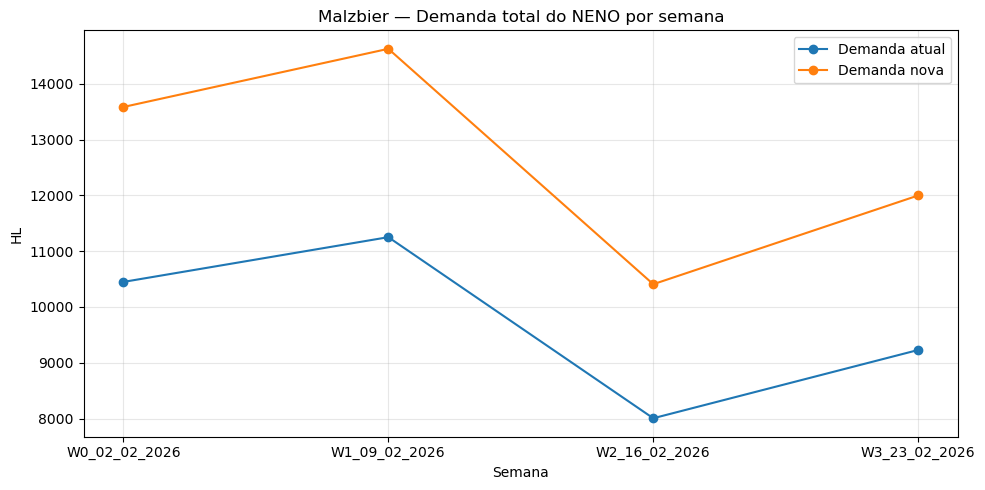

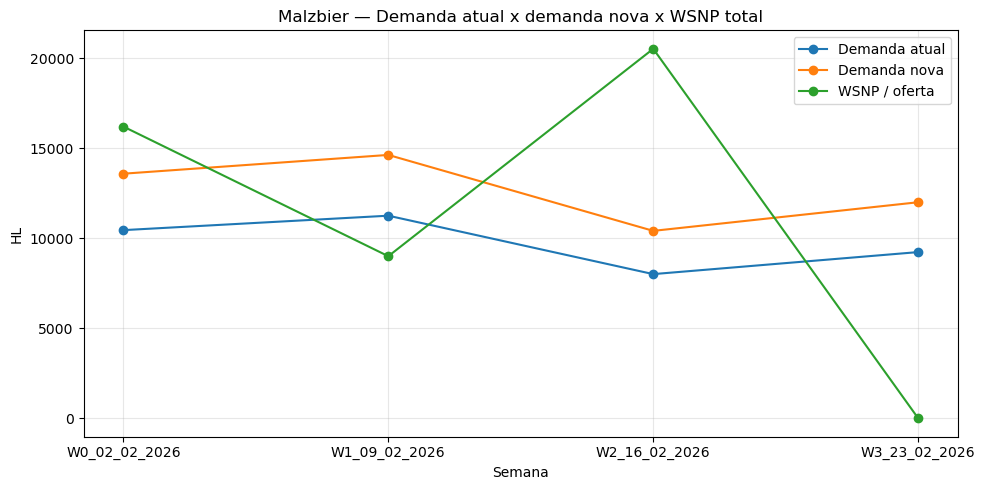

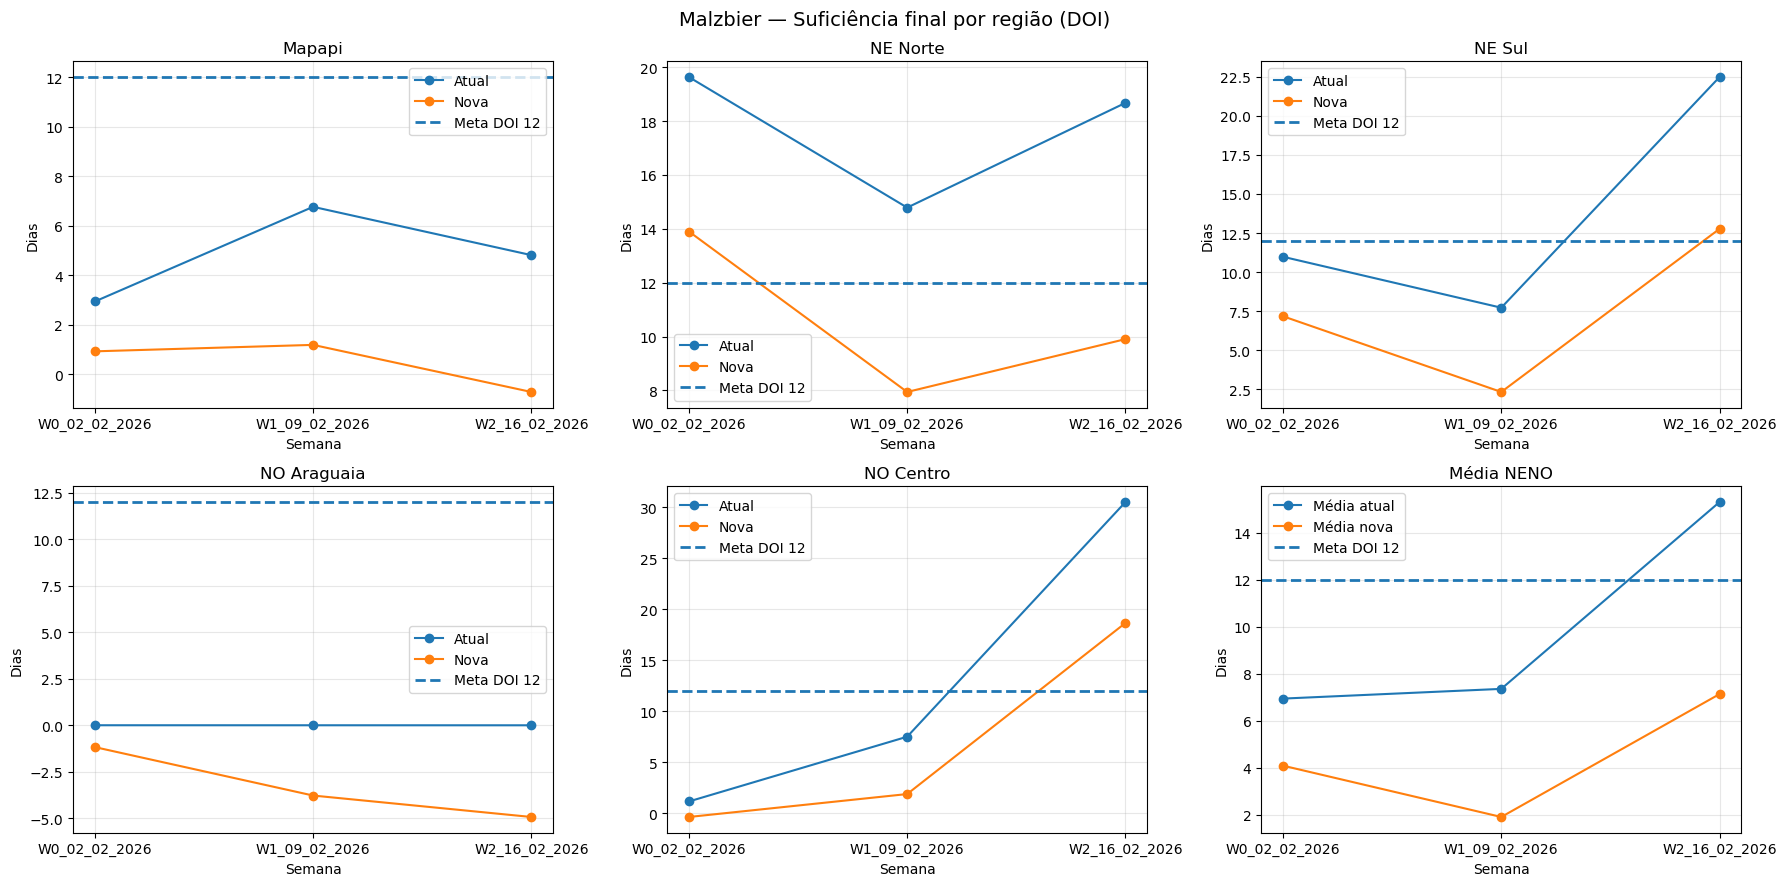

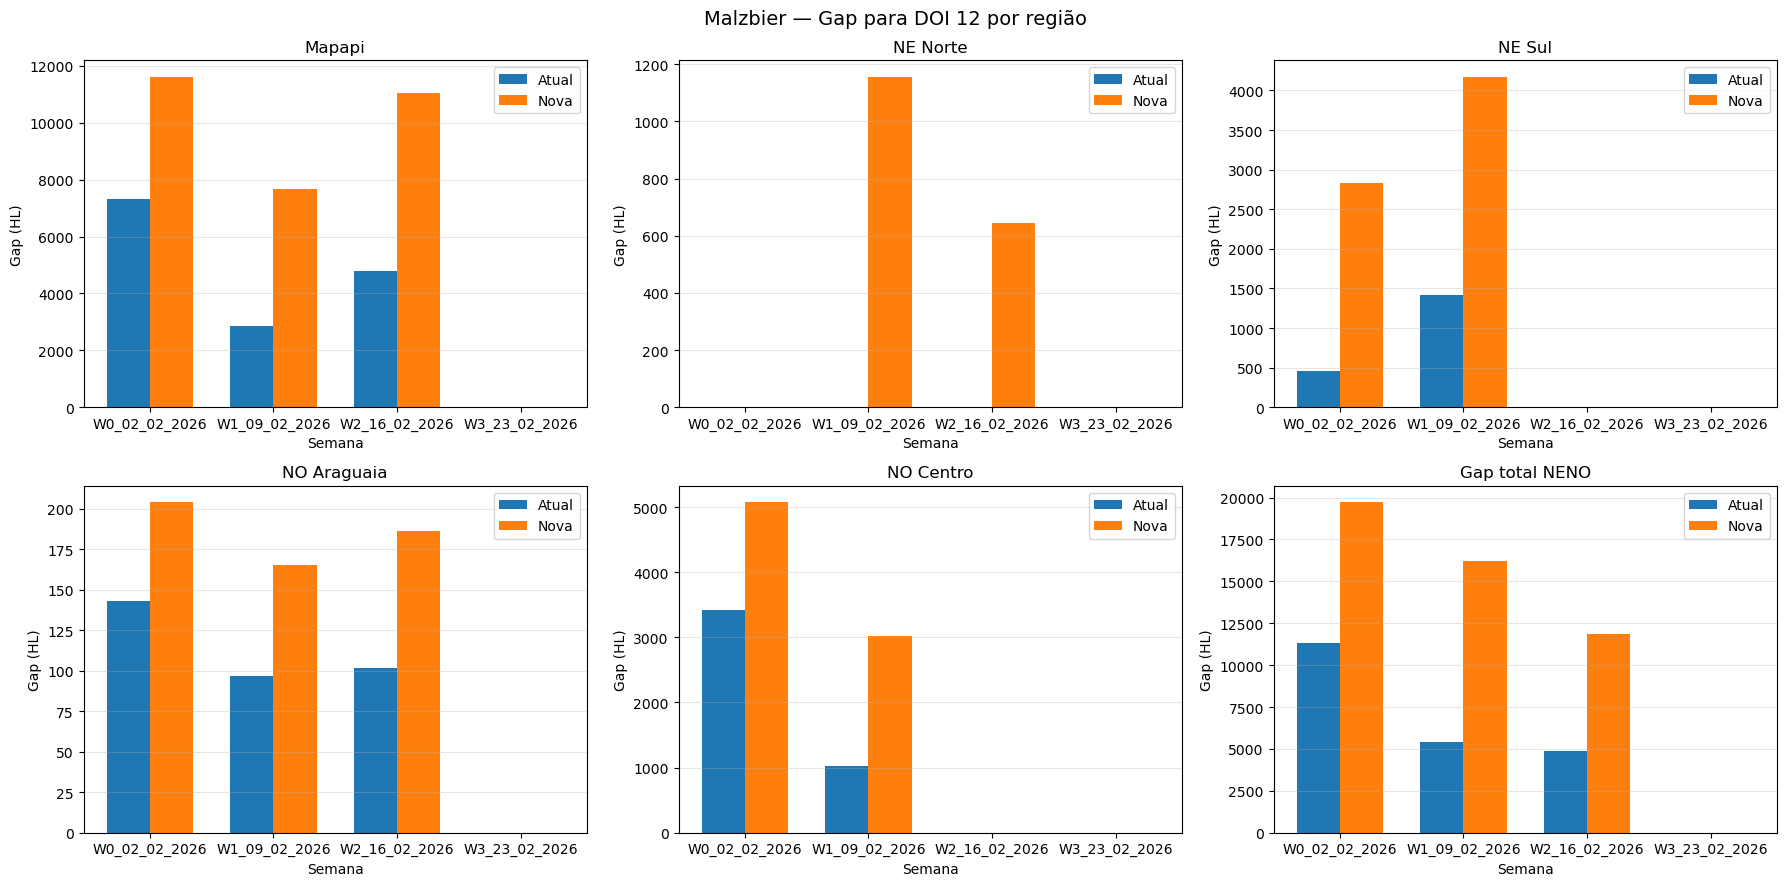

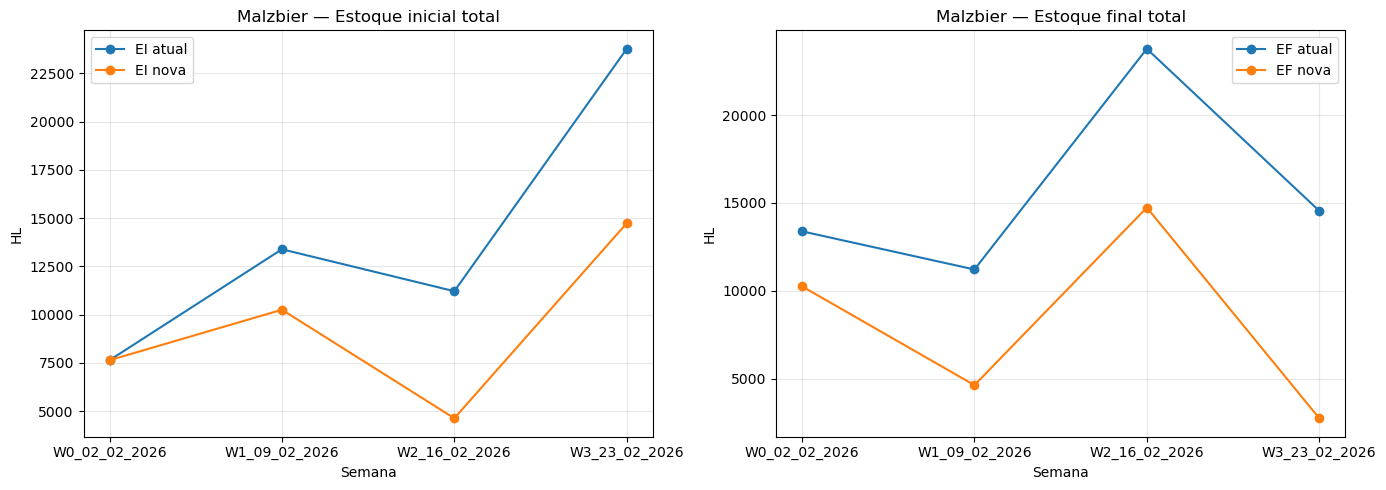

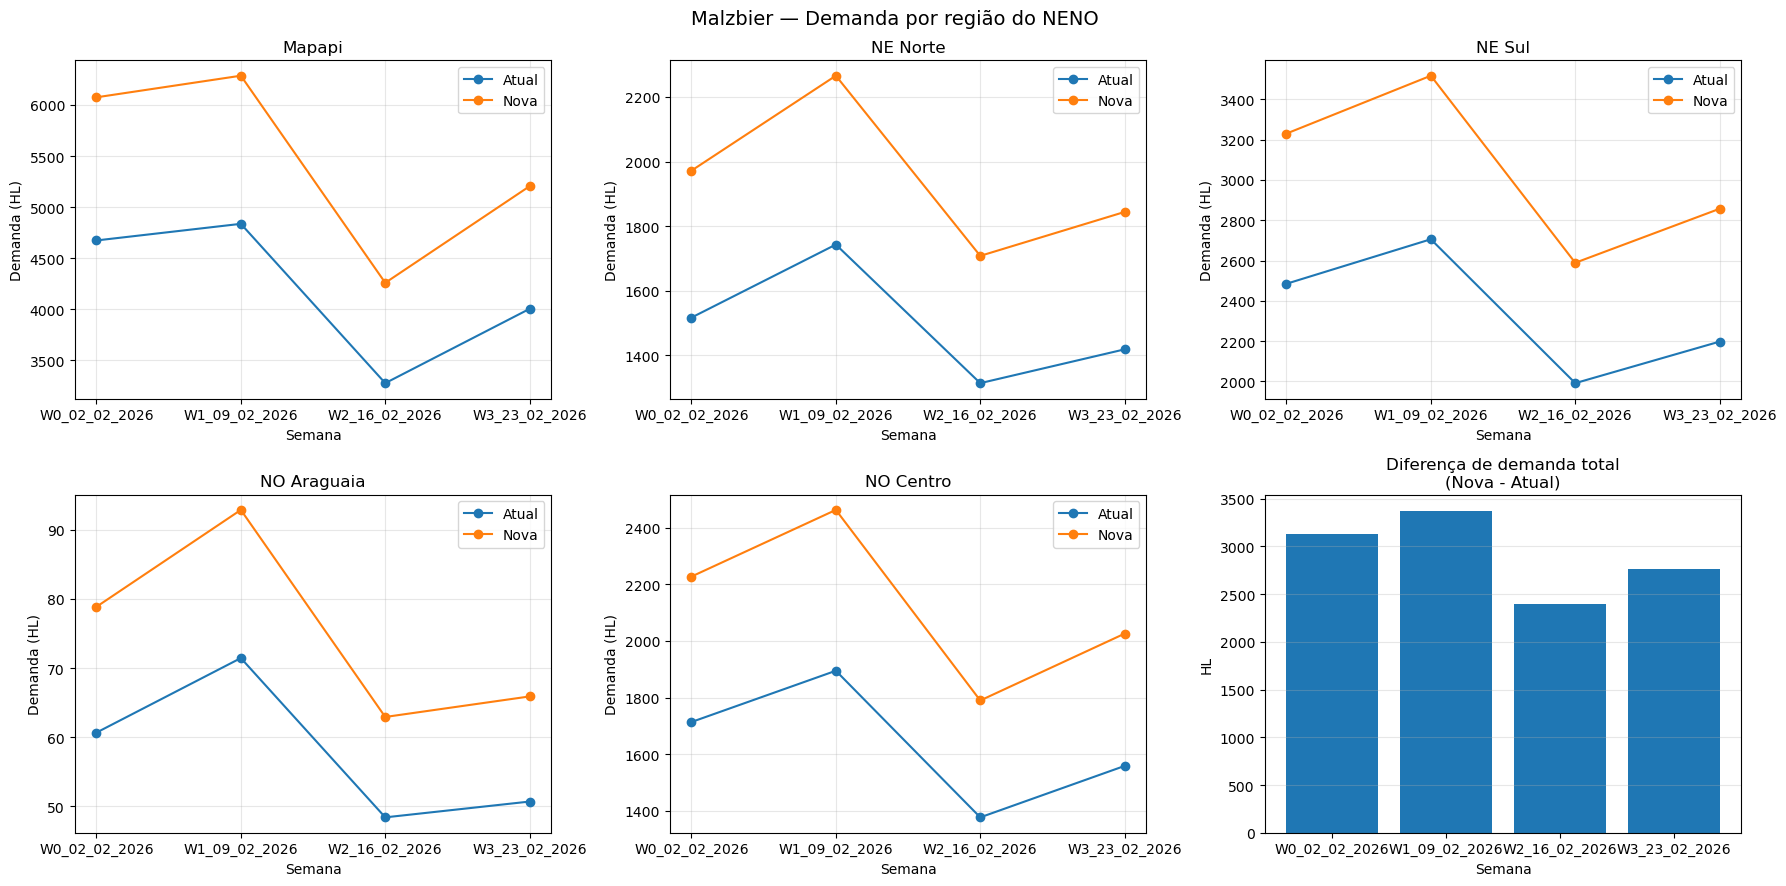

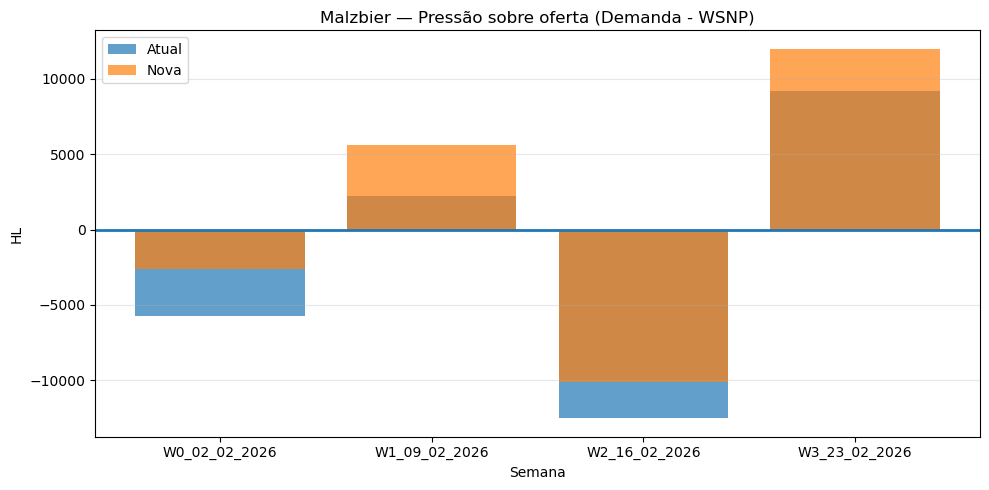

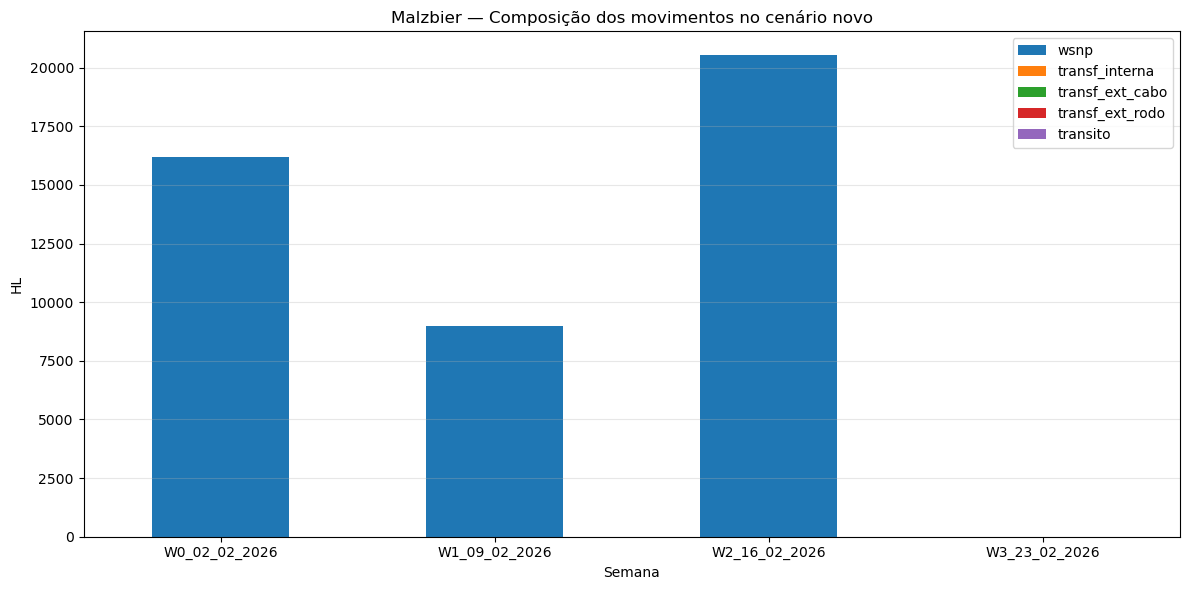

C:\Users\capoz\AppData\Local\Temp\ipykernel_27084\3148296150.py:255: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  nova.pivot_table(


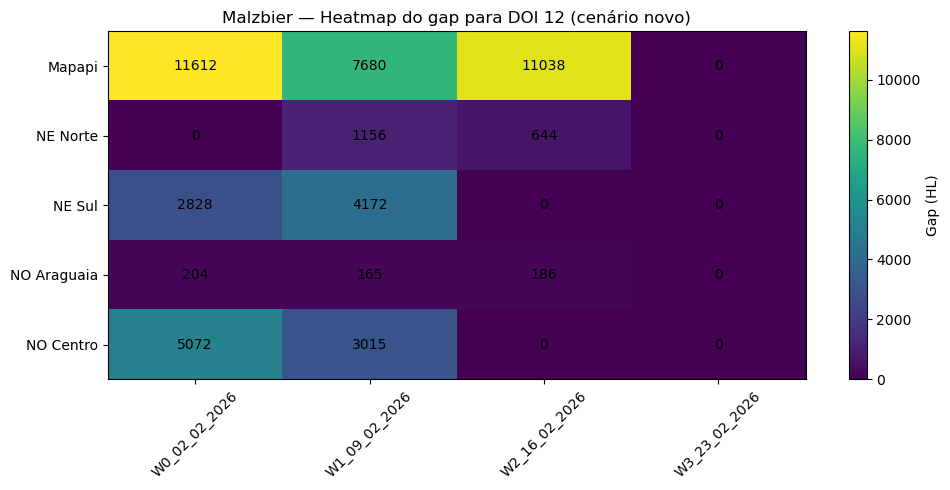

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# CONFIGURAÇÃO
# =========================================================
REGIOES_NENO = ["Mapapi", "NE Norte", "NE Sul", "NO Araguaia", "NO Centro"]
ORDEM_SEMANAS = ["W0_02_02_2026", "W1_09_02_2026", "W2_16_02_2026", "W3_23_02_2026"]

def prepara_base_neno(df):
    base = df.copy()
    base = base[df["geo_reg"].isin(REGIOES_NENO)].copy()
    base["semana"] = pd.Categorical(base["semana"], categories=ORDEM_SEMANAS, ordered=True)
    base = base.sort_values(["geo_reg", "semana"])
    return base

# bases
atual = prepara_base_neno(malzbier_atual)
nova = prepara_base_neno(malzbier_nova)

# agregados totais
resumo_atual = (
    atual.groupby("semana", observed=False)[
        ["demanda_semana", "wsnp", "ei_semana", "ef_semana", "gap_ef_12", "surplus_ef_12", "suf_f_d"]
    ]
    .sum()
    .reindex(ORDEM_SEMANAS)
)

resumo_nova = (
    nova.groupby("semana", observed=False)[
        ["demanda_semana", "wsnp", "ei_semana", "ef_semana", "gap_ef_12", "surplus_ef_12", "suf_f_d"]
    ]
    .sum()
    .reindex(ORDEM_SEMANAS)
)

# para suficiência total agregada, média por região é mais interpretável
suf_media_atual = (
    atual.groupby("semana", observed=False)["suf_f_d"]
    .mean()
    .reindex(ORDEM_SEMANAS)
)

suf_media_nova = (
    nova.groupby("semana", observed=False)["suf_f_d"]
    .mean()
    .reindex(ORDEM_SEMANAS)
)

# =========================================================
# 1) DEMANDA ATUAL x DEMANDA NOVA
# =========================================================
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(resumo_atual.index, resumo_atual["demanda_semana"], marker="o", label="Demanda atual")
ax.plot(resumo_nova.index, resumo_nova["demanda_semana"], marker="o", label="Demanda nova")
ax.set_title("Malzbier — Demanda total do NENO por semana")
ax.set_xlabel("Semana")
ax.set_ylabel("HL")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

# =========================================================
# 2) DEMANDA x WSNP / OFERTA
# =========================================================
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(resumo_atual.index, resumo_atual["demanda_semana"], marker="o", label="Demanda atual")
ax.plot(resumo_nova.index, resumo_nova["demanda_semana"], marker="o", label="Demanda nova")
ax.plot(resumo_nova.index, resumo_nova["wsnp"], marker="o", label="WSNP / oferta")
ax.set_title("Malzbier — Demanda atual x demanda nova x WSNP total")
ax.set_xlabel("Semana")
ax.set_ylabel("HL")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

# =========================================================
# 3) DOI / SUFICIÊNCIA FINAL POR REGIÃO
# =========================================================
fig, axes = plt.subplots(2, 3, figsize=(18, 9))
axes = axes.flatten()
fig.suptitle("Malzbier — Suficiência final por região (DOI)", fontsize=14)

for i, regiao in enumerate(REGIOES_NENO):
    ax = axes[i]
    atual_reg = atual[atual["geo_reg"] == regiao]
    nova_reg = nova[nova["geo_reg"] == regiao]

    ax.plot(atual_reg["semana"], atual_reg["suf_f_d"], marker="o", label="Atual")
    ax.plot(nova_reg["semana"], nova_reg["suf_f_d"], marker="o", label="Nova")
    ax.axhline(12, linestyle="--", linewidth=2, label="Meta DOI 12")
    ax.set_title(regiao)
    ax.set_xlabel("Semana")
    ax.set_ylabel("Dias")
    ax.grid(True, alpha=0.3)
    ax.legend()

axes[5].plot(suf_media_atual.index, suf_media_atual.values, marker="o", label="Média atual")
axes[5].plot(suf_media_nova.index, suf_media_nova.values, marker="o", label="Média nova")
axes[5].axhline(12, linestyle="--", linewidth=2, label="Meta DOI 12")
axes[5].set_title("Média NENO")
axes[5].set_xlabel("Semana")
axes[5].set_ylabel("Dias")
axes[5].grid(True, alpha=0.3)
axes[5].legend()

plt.tight_layout()
plt.show()

# =========================================================
# 4) GAP PARA DOI 12 POR REGIÃO
# =========================================================
fig, axes = plt.subplots(2, 3, figsize=(18, 9))
axes = axes.flatten()
fig.suptitle("Malzbier — Gap para DOI 12 por região", fontsize=14)

for i, regiao in enumerate(REGIOES_NENO):
    ax = axes[i]
    atual_reg = atual[atual["geo_reg"] == regiao]
    nova_reg = nova[nova["geo_reg"] == regiao]

    x = np.arange(len(ORDEM_SEMANAS))
    largura = 0.35

    atual_vals = atual_reg.set_index("semana").reindex(ORDEM_SEMANAS)["gap_ef_12"].fillna(0).values
    nova_vals = nova_reg.set_index("semana").reindex(ORDEM_SEMANAS)["gap_ef_12"].fillna(0).values

    ax.bar(x - largura/2, atual_vals, largura, label="Atual")
    ax.bar(x + largura/2, nova_vals, largura, label="Nova")
    ax.set_title(regiao)
    ax.set_xlabel("Semana")
    ax.set_ylabel("Gap (HL)")
    ax.set_xticks(x)
    ax.set_xticklabels(ORDEM_SEMANAS)
    ax.grid(True, axis="y", alpha=0.3)
    ax.legend()

x = np.arange(len(ORDEM_SEMANAS))
largura = 0.35
axes[5].bar(x - largura/2, resumo_atual["gap_ef_12"].values, largura, label="Atual")
axes[5].bar(x + largura/2, resumo_nova["gap_ef_12"].values, largura, label="Nova")
axes[5].set_title("Gap total NENO")
axes[5].set_xlabel("Semana")
axes[5].set_ylabel("Gap (HL)")
axes[5].set_xticks(x)
axes[5].set_xticklabels(ORDEM_SEMANAS)
axes[5].grid(True, axis="y", alpha=0.3)
axes[5].legend()

plt.tight_layout()
plt.show()

# =========================================================
# 5) ESTOQUE INICIAL x ESTOQUE FINAL
# =========================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(resumo_atual.index, resumo_atual["ei_semana"], marker="o", label="EI atual")
axes[0].plot(resumo_nova.index, resumo_nova["ei_semana"], marker="o", label="EI nova")
axes[0].set_title("Malzbier — Estoque inicial total")
axes[0].set_xlabel("Semana")
axes[0].set_ylabel("HL")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(resumo_atual.index, resumo_atual["ef_semana"], marker="o", label="EF atual")
axes[1].plot(resumo_nova.index, resumo_nova["ef_semana"], marker="o", label="EF nova")
axes[1].set_title("Malzbier — Estoque final total")
axes[1].set_xlabel("Semana")
axes[1].set_ylabel("HL")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

# =========================================================
# 6) DEMANDA POR REGIÃO
# =========================================================
fig, axes = plt.subplots(2, 3, figsize=(18, 9))
axes = axes.flatten()
fig.suptitle("Malzbier — Demanda por região do NENO", fontsize=14)

for i, regiao in enumerate(REGIOES_NENO):
    ax = axes[i]
    atual_reg = atual[atual["geo_reg"] == regiao]
    nova_reg = nova[nova["geo_reg"] == regiao]

    ax.plot(atual_reg["semana"], atual_reg["demanda_semana"], marker="o", label="Atual")
    ax.plot(nova_reg["semana"], nova_reg["demanda_semana"], marker="o", label="Nova")
    ax.set_title(regiao)
    ax.set_xlabel("Semana")
    ax.set_ylabel("Demanda (HL)")
    ax.grid(True, alpha=0.3)
    ax.legend()

dif_demanda = (resumo_nova["demanda_semana"] - resumo_atual["demanda_semana"]).fillna(0)
axes[5].bar(dif_demanda.index.astype(str), dif_demanda.values)
axes[5].set_title("Diferença de demanda total\n(Nova - Atual)")
axes[5].set_xlabel("Semana")
axes[5].set_ylabel("HL")
axes[5].grid(True, axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

# =========================================================
# 7) PRESSÃO SOBRE A OFERTA
# =========================================================
pressao_nova = (resumo_nova["demanda_semana"] - resumo_nova["wsnp"]).fillna(0)
pressao_atual = (resumo_atual["demanda_semana"] - resumo_atual["wsnp"]).fillna(0)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(pressao_atual.index.astype(str), pressao_atual.values, alpha=0.7, label="Atual")
ax.bar(pressao_nova.index.astype(str), pressao_nova.values, alpha=0.7, label="Nova")
ax.axhline(0, linewidth=2)
ax.set_title("Malzbier — Pressão sobre oferta (Demanda - WSNP)")
ax.set_xlabel("Semana")
ax.set_ylabel("HL")
ax.grid(True, axis="y", alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

# =========================================================
# 8) COMPOSIÇÃO DOS MOVIMENTOS - CENÁRIO NOVO
# =========================================================
comp_nova = (
    nova.groupby("semana", observed=False)[
        ["wsnp", "transf_interna", "transf_ext_cabo", "transf_ext_rodo", "transito"]
    ]
    .sum()
    .reindex(ORDEM_SEMANAS)
    .fillna(0)
)

fig, ax = plt.subplots(figsize=(12, 6))
comp_nova.plot(kind="bar", stacked=True, ax=ax)
ax.set_title("Malzbier — Composição dos movimentos no cenário novo")
ax.set_xlabel("Semana")
ax.set_ylabel("HL")
ax.grid(True, axis="y", alpha=0.3)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# =========================================================
# 9) HEATMAP SIMPLES DO GAP NO CENÁRIO NOVO
# =========================================================
pivot_gap = (
    nova.pivot_table(
        index="geo_reg",
        columns="semana",
        values="gap_ef_12",
        aggfunc="sum"
    )
    .reindex(index=REGIOES_NENO, columns=ORDEM_SEMANAS)
    .fillna(0)
)

fig, ax = plt.subplots(figsize=(10, 5))
im = ax.imshow(pivot_gap.values, aspect="auto")

ax.set_title("Malzbier — Heatmap do gap para DOI 12 (cenário novo)")
ax.set_xticks(range(len(pivot_gap.columns)))
ax.set_xticklabels(pivot_gap.columns, rotation=45)
ax.set_yticks(range(len(pivot_gap.index)))
ax.set_yticklabels(pivot_gap.index)

for i in range(pivot_gap.shape[0]):
    for j in range(pivot_gap.shape[1]):
        ax.text(j, i, f"{pivot_gap.iloc[i, j]:.0f}", ha="center", va="center")

plt.colorbar(im, ax=ax, label="Gap (HL)")
plt.tight_layout()
plt.show()

## 4) Análise comparativa de fevereiro e março para todas as cervejas

Neste bloco, foram construídos gráficos comparativos para avaliar o comportamento das quatro cervejas (**Patagonia, Goose, Malzbier e Colorado**) no NENO ao longo de **fevereiro e março**, considerando tanto o **cenário atual** quanto o **cenário novo**.

### O que foi feito

- Foram definidas:
  - as regiões do NENO consideradas na análise
  - a ordem das semanas de fevereiro e março
  - rótulos simplificados do eixo x (`W0` a `W7`) para melhorar a leitura dos gráficos

- Foi criado um dicionário com os pares de bases de cada cerveja:
  - cenário atual com março
  - cenário novo com março

- Também foi criado um dicionário com a **capacidade produtiva máxima semanal** de cada cerveja, com base nas plantas que podem produzi-las:
  - **Patagonia**: somente CE
  - **Goose**: somente PE
  - **Malzbier**: CE + PE
  - **Colorado**: CE + PE
  - além da capacidade máxima conjunta total

- Foi utilizada uma função auxiliar para:
  - filtrar apenas as regiões do NENO
  - ordenar corretamente as semanas
  - deixar as bases prontas para agregação e plotagem

### Gráficos gerados

**1. Demanda total por cerveja e semana**
- Compara, para cada cerveja, a demanda total no NENO entre cenário atual e cenário novo.

**2. Pressão sobre oferta**
- Mede a diferença entre `demanda_semana` e `wsnp`.
- Esse gráfico ajuda a identificar em quais semanas a demanda supera a oferta programada.

**3. DOI médio por cerveja**
- Mostra a suficiência final média em dias ao longo das semanas.
- Inclui uma linha de referência na meta de **DOI 12**.

**4. Gap total para DOI 12**
- Mostra, por cerveja, o volume faltante total para atingir a meta de cobertura mínima.

**5. Capacidade produtiva máxima x demanda total das quatro cervejas**
- Compara a demanda agregada de todas as cervejas com a capacidade máxima produtiva total disponível.
- Esse gráfico ajuda a avaliar se a limitação é apenas logística ou se existe risco estrutural de produção.

**6. Capacidade produtiva máxima x demanda por cerveja**
- Faz a mesma comparação individualmente para cada cerveja.
- Permite verificar se a demanda semanal se aproxima ou ultrapassa a capacidade máxima disponível para aquele SKU.

### Resultado

Ao final do bloco, foram geradas visualizações que permitem analisar, para cada cerveja e também de forma consolidada:

- a evolução da demanda em fevereiro e março
- o impacto do cenário novo sobre a oferta
- a manutenção ou não do DOI 12
- o aumento de gaps de cobertura
- a proximidade entre demanda e capacidade produtiva máxima

Esses gráficos ajudam a entender se o problema é apenas de redistribuição e estoque ou se também existe restrição produtiva relevante para sustentar o crescimento de demanda.

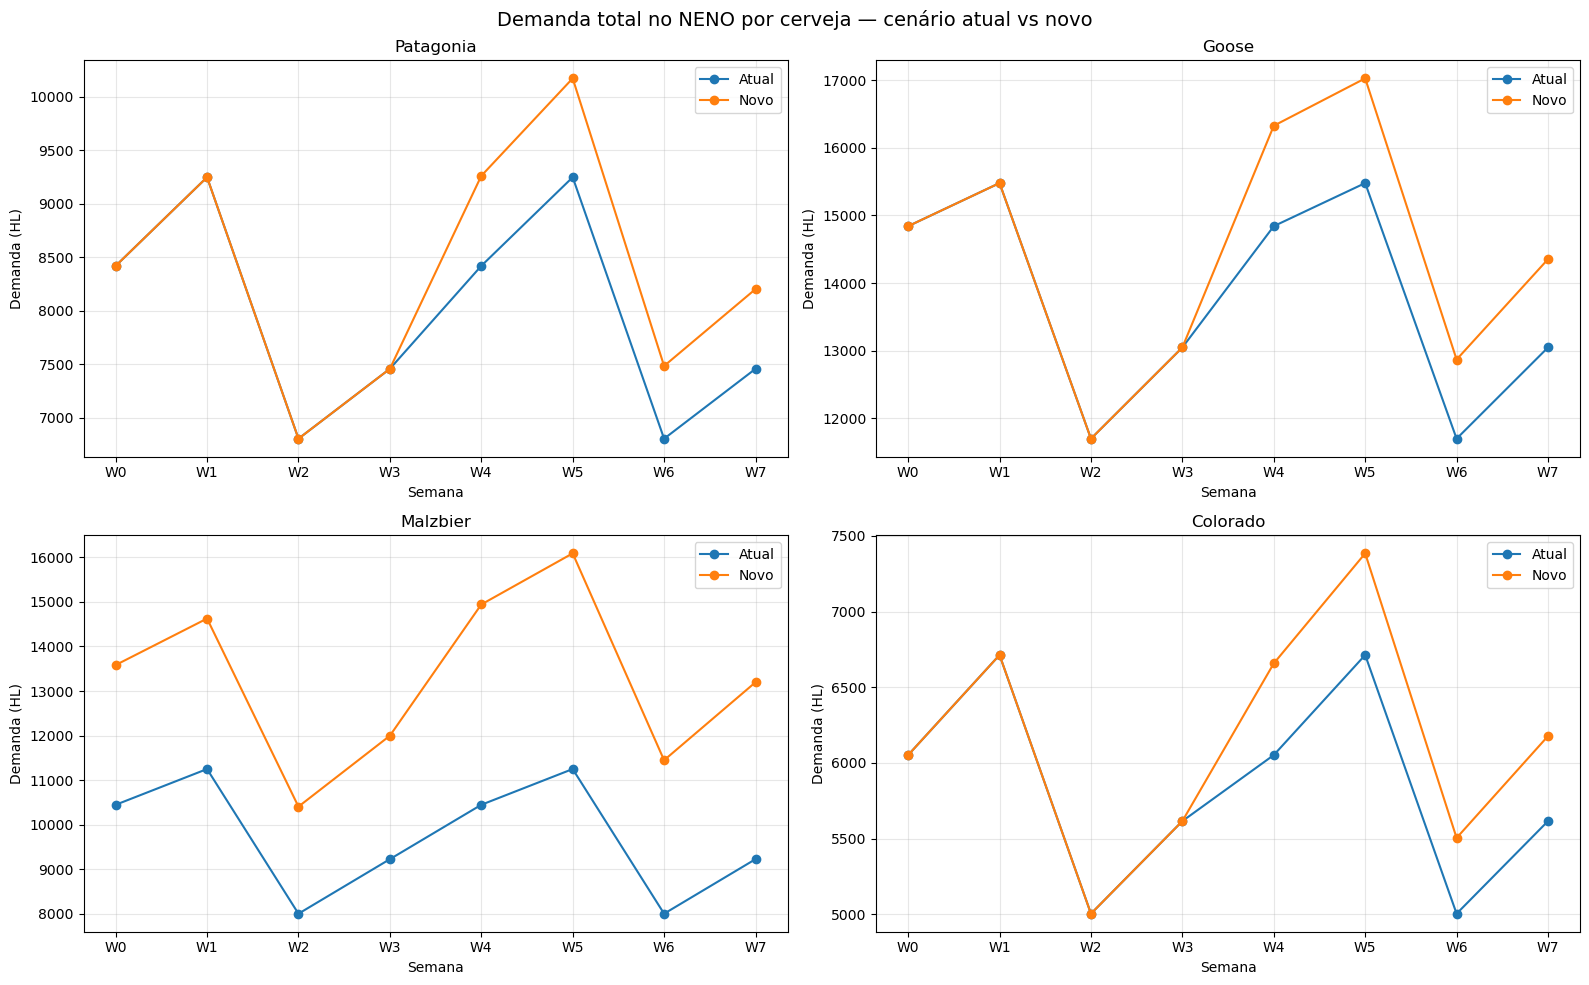

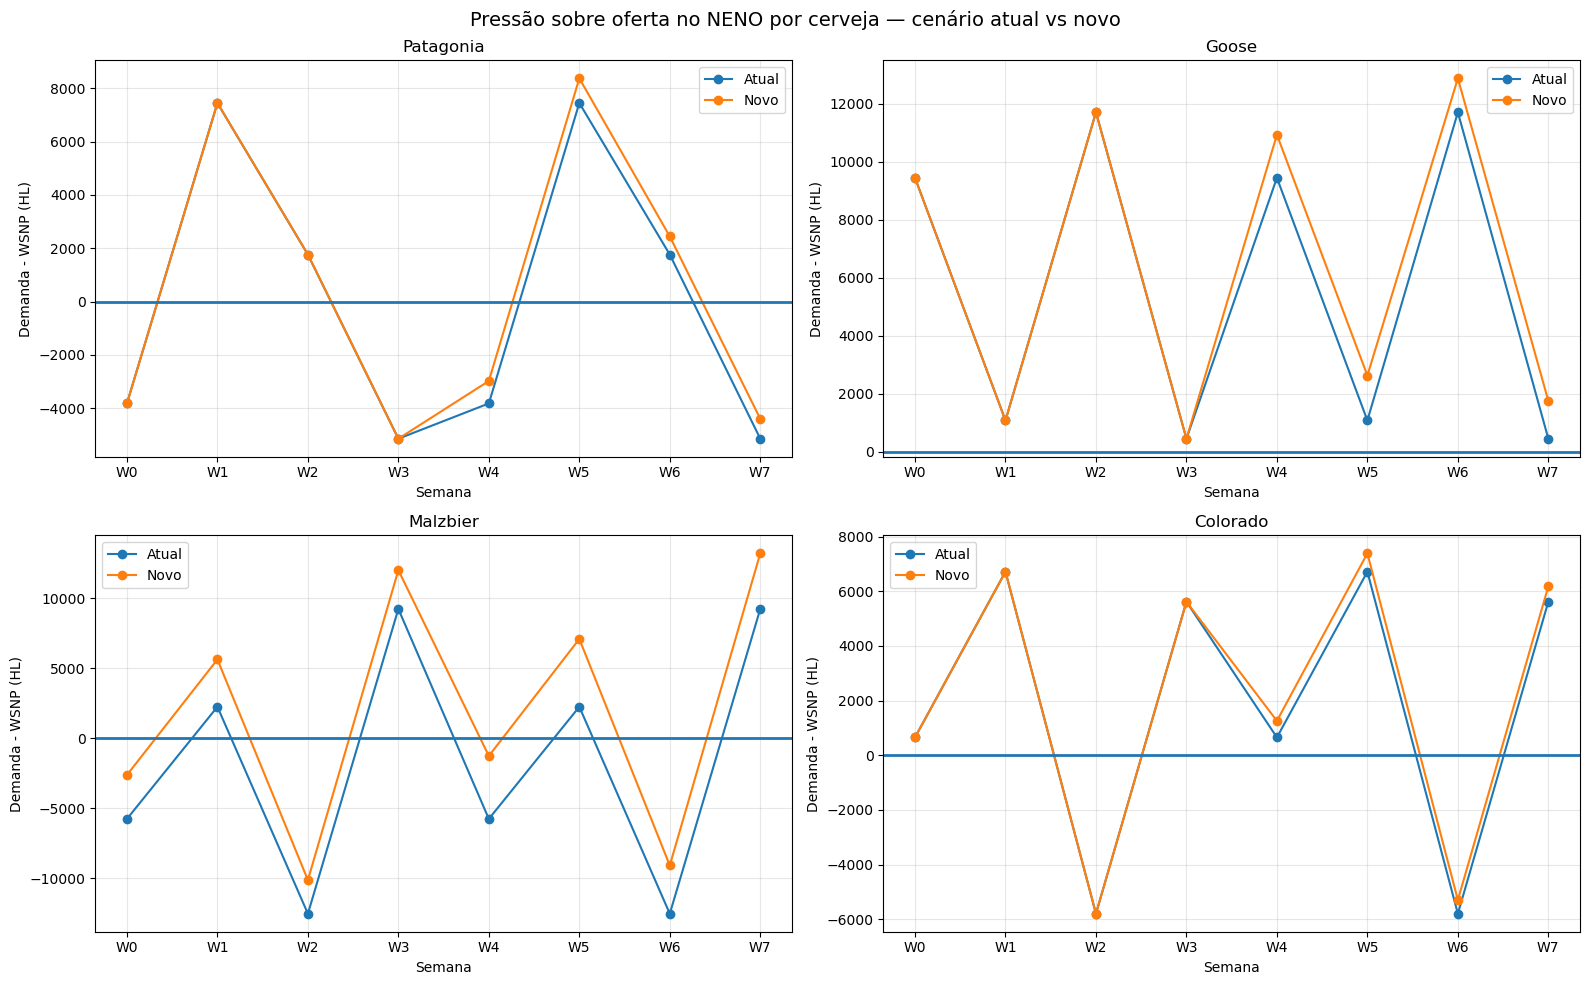

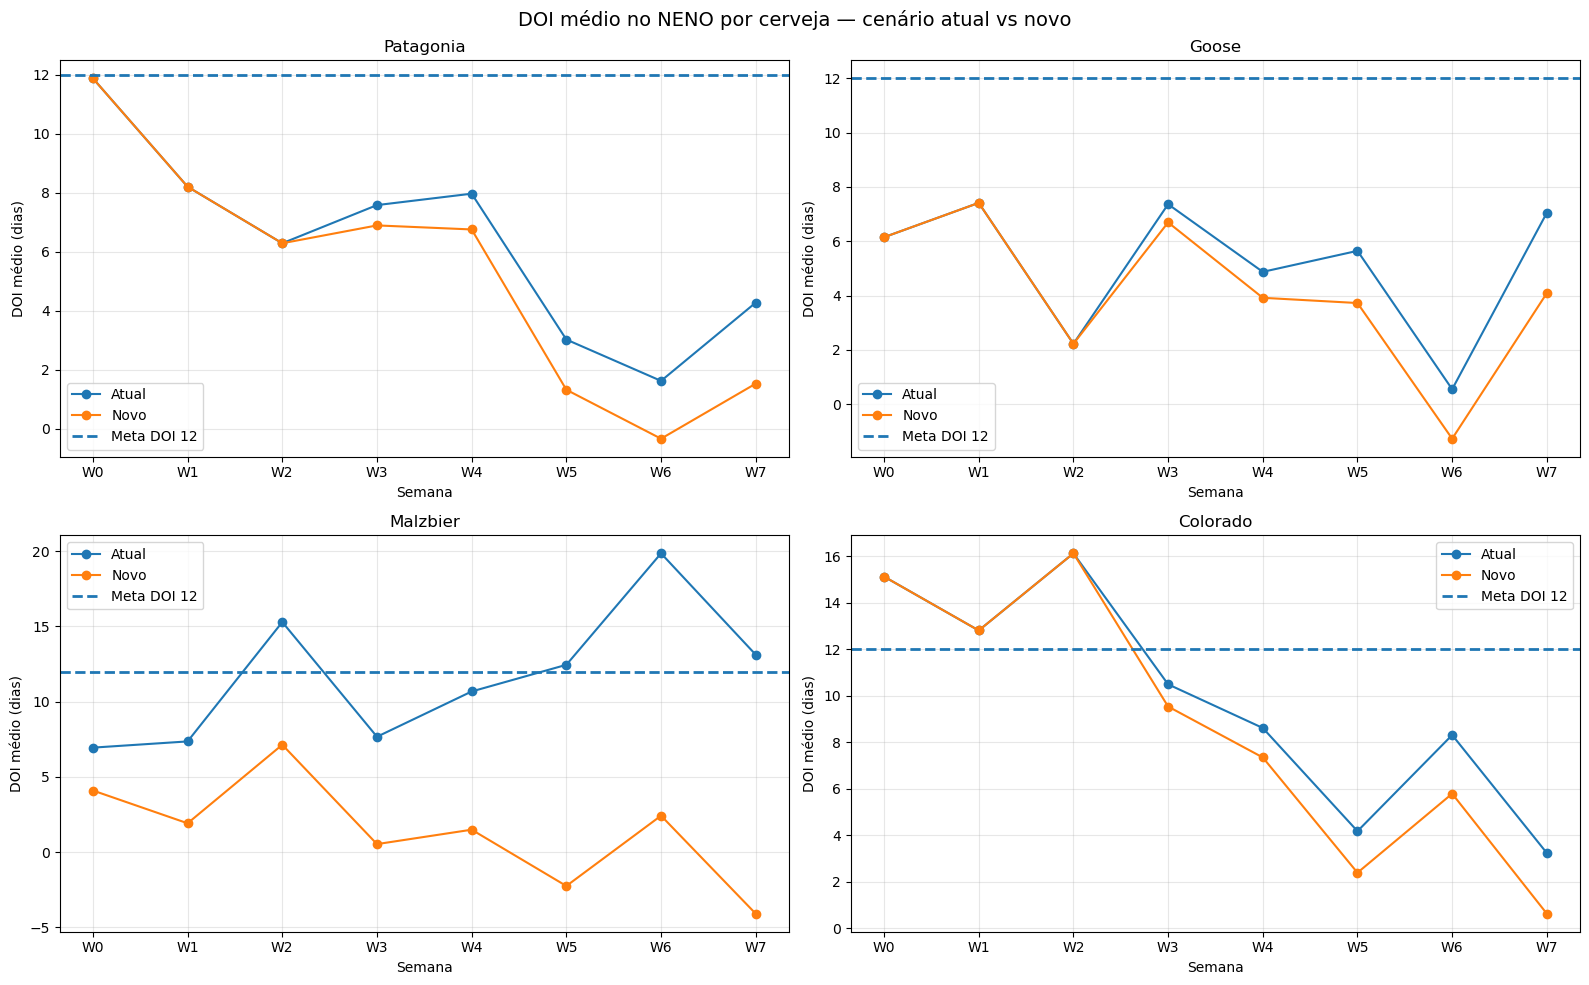

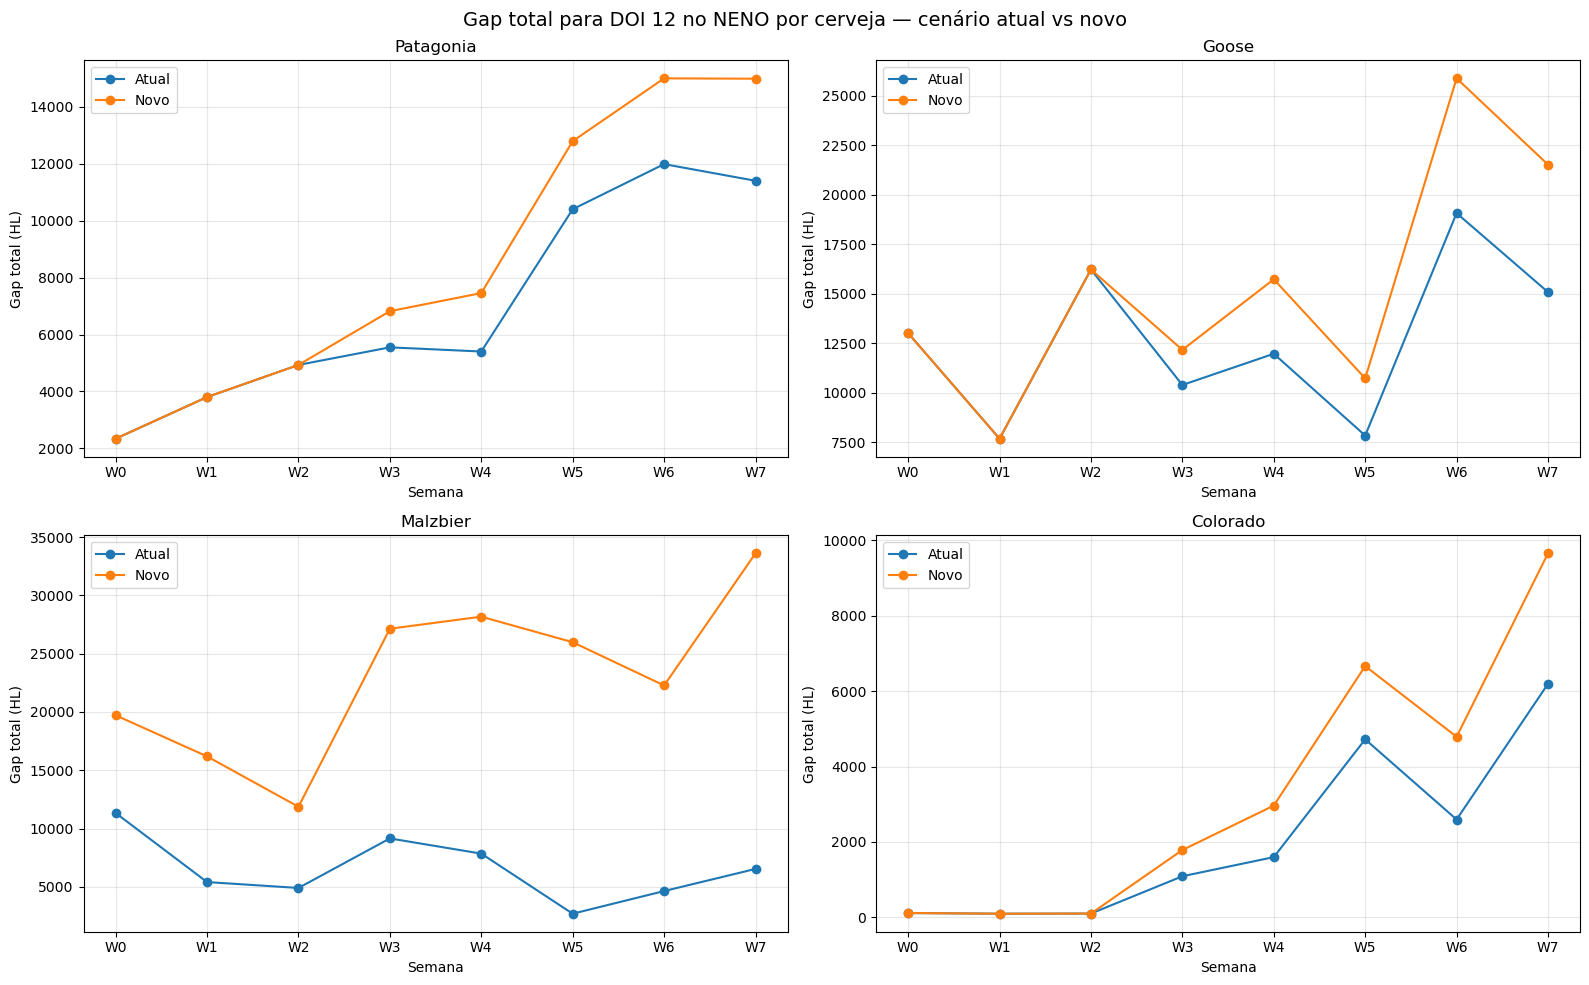

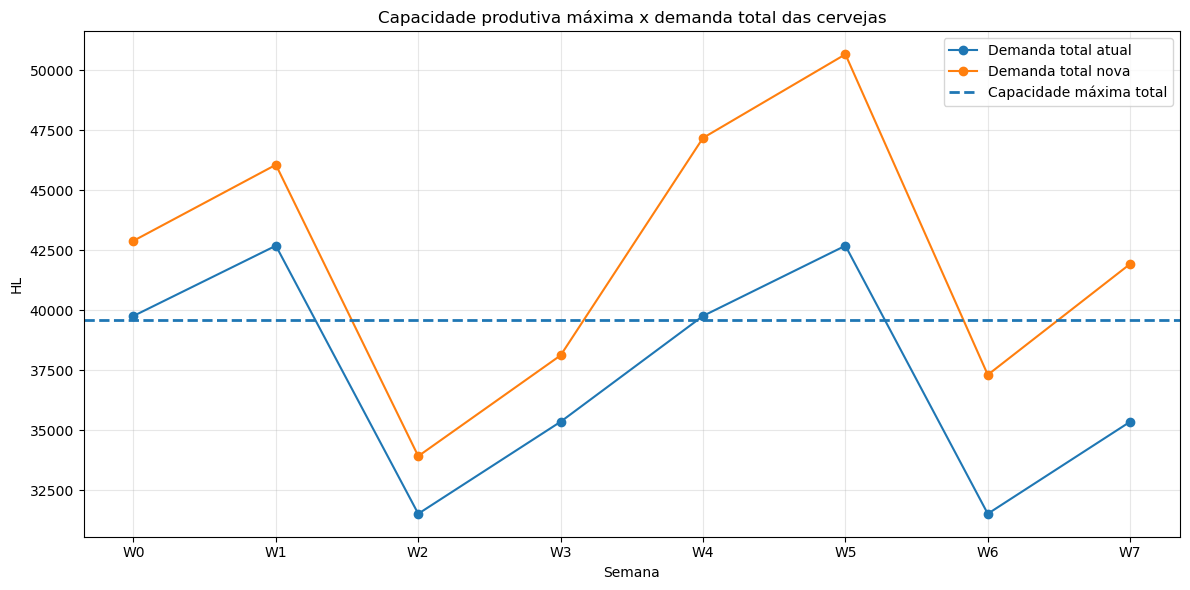

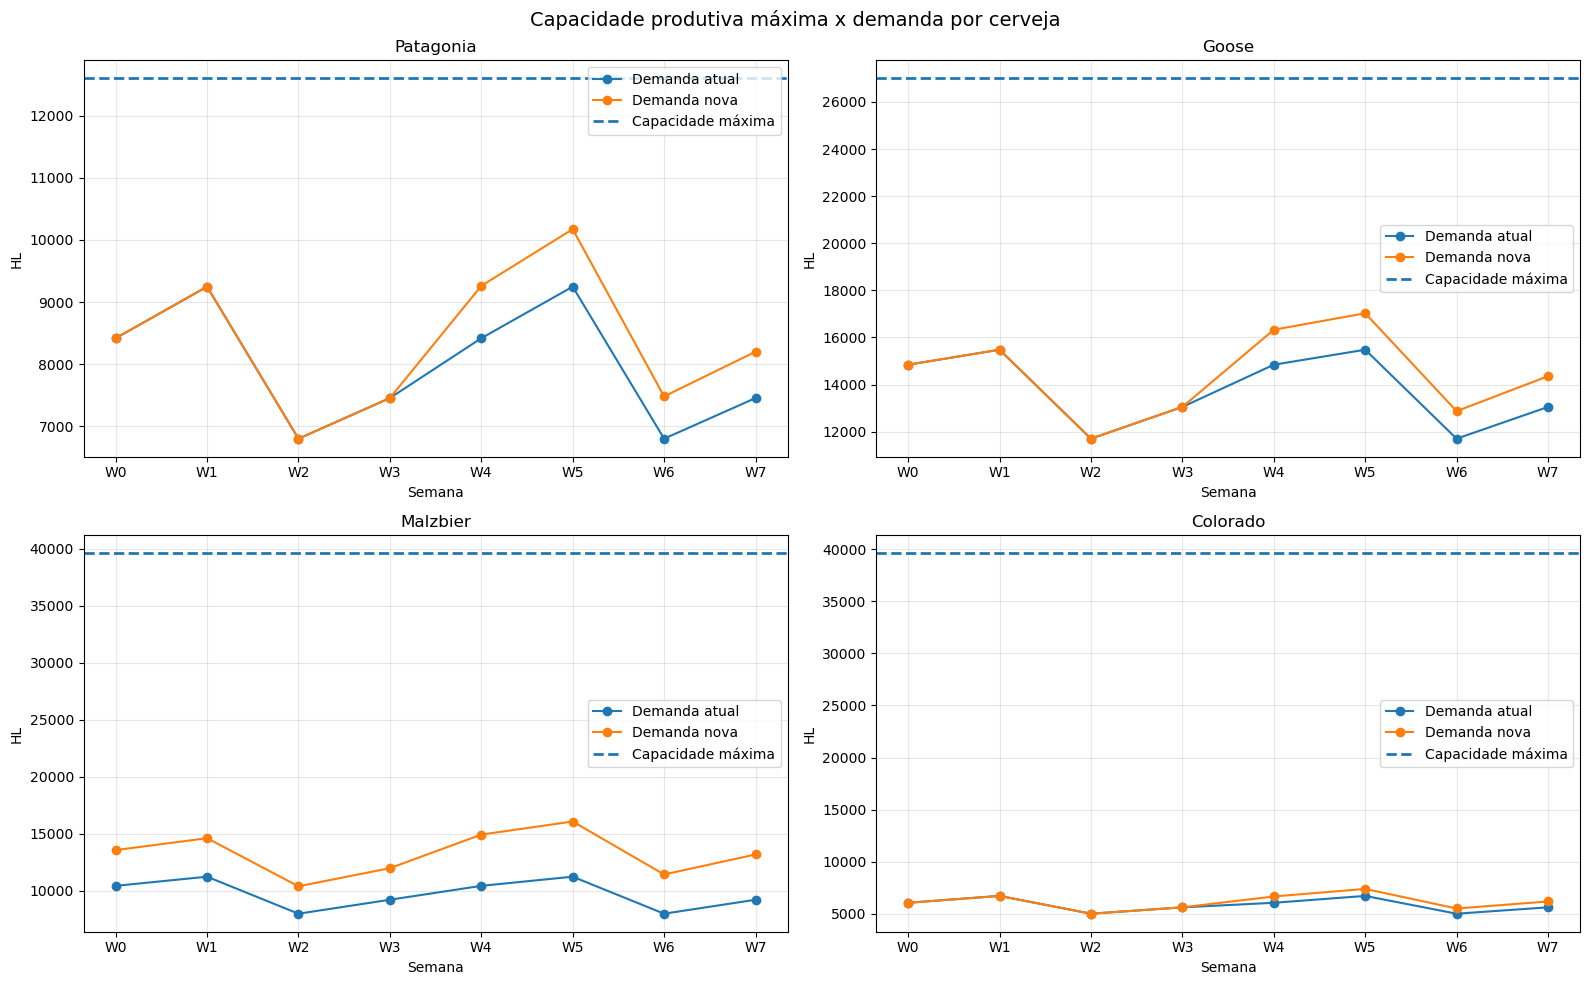

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# CONFIGURAÇÃO
# =========================================================
REGIOES_NENO = ["Mapapi", "NE Norte", "NE Sul", "NO Araguaia", "NO Centro"]

ORDEM_SEMANAS = [
    "W0_02_02_2026",
    "W1_09_02_2026",
    "W2_16_02_2026",
    "W3_23_02_2026",
    "W4_02_03_2026",
    "W5_09_03_2026",
    "W6_16_03_2026",
    "W7_23_03_2026"
]

LABELS_SEMANAS = ["W0", "W1", "W2", "W3", "W4", "W5", "W6", "W7"]
X = np.arange(len(ORDEM_SEMANAS))

PARES_CERVEJAS = {
    "Patagonia": (patagonia_atual_mar, patagonia_nova_mar),
    "Goose": (goose_atual_mar, goose_nova_mar),
    "Malzbier": (malzbier_atual_mar, malzbier_nova_mar),
    "Colorado": (colorado_atual_mar, colorado_nova_mar),
}

# capacidade máxima semanal por cerveja (hl/semana)
CAPACIDADE_MAXIMA = {
    "Patagonia": 12600,   # somente CE
    "Goose": 27000,       # somente PE
    "Malzbier": 39600,    # CE + PE
    "Colorado": 39600,    # CE + PE
    "Total": 39600        # capacidade conjunta CE + PE
}

def prepara_base_neno(df):
    base = df.copy()
    base = base[base["geo_reg"].isin(REGIOES_NENO)].copy()
    base["semana"] = pd.Categorical(base["semana"], categories=ORDEM_SEMANAS, ordered=True)
    base = base.sort_values(["geo_reg", "semana"])
    return base

# =========================================================
# 1) DEMANDA TOTAL POR CERVEJA E SEMANA
# =========================================================
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()
fig.suptitle("Demanda total no NENO por cerveja — cenário atual vs novo", fontsize=14)

for i, (nome, (df_atual, df_nova)) in enumerate(PARES_CERVEJAS.items()):
    ax = axes[i]

    atual = prepara_base_neno(df_atual)
    nova = prepara_base_neno(df_nova)

    resumo_atual = (
        atual.groupby("semana", observed=False)["demanda_semana"]
        .sum()
        .reindex(ORDEM_SEMANAS)
    )
    resumo_nova = (
        nova.groupby("semana", observed=False)["demanda_semana"]
        .sum()
        .reindex(ORDEM_SEMANAS)
    )

    ax.plot(X, resumo_atual.values, marker="o", label="Atual")
    ax.plot(X, resumo_nova.values, marker="o", label="Novo")
    ax.set_title(nome)
    ax.set_xlabel("Semana")
    ax.set_ylabel("Demanda (HL)")
    ax.set_xticks(X)
    ax.set_xticklabels(LABELS_SEMANAS)
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

# =========================================================
# 2) PRESSÃO SOBRE OFERTA (DEMANDA - WSNP)
# =========================================================
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()
fig.suptitle("Pressão sobre oferta no NENO por cerveja — cenário atual vs novo", fontsize=14)

for i, (nome, (df_atual, df_nova)) in enumerate(PARES_CERVEJAS.items()):
    ax = axes[i]

    atual = prepara_base_neno(df_atual)
    nova = prepara_base_neno(df_nova)

    resumo_atual = (
        atual.groupby("semana", observed=False)[["demanda_semana", "wsnp"]]
        .sum()
        .reindex(ORDEM_SEMANAS)
    )
    resumo_nova = (
        nova.groupby("semana", observed=False)[["demanda_semana", "wsnp"]]
        .sum()
        .reindex(ORDEM_SEMANAS)
    )

    pressao_atual = resumo_atual["demanda_semana"] - resumo_atual["wsnp"]
    pressao_nova = resumo_nova["demanda_semana"] - resumo_nova["wsnp"]

    ax.plot(X, pressao_atual.values, marker="o", label="Atual")
    ax.plot(X, pressao_nova.values, marker="o", label="Novo")
    ax.axhline(0, linewidth=2)
    ax.set_title(nome)
    ax.set_xlabel("Semana")
    ax.set_ylabel("Demanda - WSNP (HL)")
    ax.set_xticks(X)
    ax.set_xticklabels(LABELS_SEMANAS)
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

# =========================================================
# 3) DOI MÉDIO POR CERVEJA
# =========================================================
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()
fig.suptitle("DOI médio no NENO por cerveja — cenário atual vs novo", fontsize=14)

for i, (nome, (df_atual, df_nova)) in enumerate(PARES_CERVEJAS.items()):
    ax = axes[i]

    atual = prepara_base_neno(df_atual)
    nova = prepara_base_neno(df_nova)

    doi_atual = (
        atual.groupby("semana", observed=False)["suf_f_d"]
        .mean()
        .reindex(ORDEM_SEMANAS)
    )
    doi_nova = (
        nova.groupby("semana", observed=False)["suf_f_d"]
        .mean()
        .reindex(ORDEM_SEMANAS)
    )

    ax.plot(X, doi_atual.values, marker="o", label="Atual")
    ax.plot(X, doi_nova.values, marker="o", label="Novo")
    ax.axhline(12, linestyle="--", linewidth=2, label="Meta DOI 12")
    ax.set_title(nome)
    ax.set_xlabel("Semana")
    ax.set_ylabel("DOI médio (dias)")
    ax.set_xticks(X)
    ax.set_xticklabels(LABELS_SEMANAS)
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

# =========================================================
# 4) GAP TOTAL PARA DOI 12
# =========================================================
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()
fig.suptitle("Gap total para DOI 12 no NENO por cerveja — cenário atual vs novo", fontsize=14)

for i, (nome, (df_atual, df_nova)) in enumerate(PARES_CERVEJAS.items()):
    ax = axes[i]

    atual = prepara_base_neno(df_atual)
    nova = prepara_base_neno(df_nova)

    gap_atual = (
        atual.groupby("semana", observed=False)["gap_ef_12"]
        .sum()
        .reindex(ORDEM_SEMANAS)
    )
    gap_nova = (
        nova.groupby("semana", observed=False)["gap_ef_12"]
        .sum()
        .reindex(ORDEM_SEMANAS)
    )

    ax.plot(X, gap_atual.values, marker="o", label="Atual")
    ax.plot(X, gap_nova.values, marker="o", label="Novo")
    ax.set_title(nome)
    ax.set_xlabel("Semana")
    ax.set_ylabel("Gap total (HL)")
    ax.set_xticks(X)
    ax.set_xticklabels(LABELS_SEMANAS)
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

# =========================================================
# 5) CAPACIDADE PRODUTIVA MÁXIMA x DEMANDA TOTAL DAS 4 CERVEJAS
# =========================================================
fig, ax = plt.subplots(figsize=(12, 6))

demanda_total_atual = pd.Series(0.0, index=ORDEM_SEMANAS)
demanda_total_nova = pd.Series(0.0, index=ORDEM_SEMANAS)

for nome, (df_atual, df_nova) in PARES_CERVEJAS.items():
    atual = prepara_base_neno(df_atual)
    nova = prepara_base_neno(df_nova)

    demanda_total_atual += (
        atual.groupby("semana", observed=False)["demanda_semana"]
        .sum()
        .reindex(ORDEM_SEMANAS)
        .fillna(0)
    )

    demanda_total_nova += (
        nova.groupby("semana", observed=False)["demanda_semana"]
        .sum()
        .reindex(ORDEM_SEMANAS)
        .fillna(0)
    )

ax.plot(X, demanda_total_atual.values, marker="o", label="Demanda total atual")
ax.plot(X, demanda_total_nova.values, marker="o", label="Demanda total nova")
ax.axhline(CAPACIDADE_MAXIMA["Total"], linestyle="--", linewidth=2, label="Capacidade máxima total")

ax.set_title("Capacidade produtiva máxima x demanda total das cervejas")
ax.set_xlabel("Semana")
ax.set_ylabel("HL")
ax.set_xticks(X)
ax.set_xticklabels(LABELS_SEMANAS)
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

# =========================================================
# 6) CAPACIDADE PRODUTIVA MÁXIMA x DEMANDA — UMA FIGURA POR CERVEJA
# =========================================================
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()
fig.suptitle("Capacidade produtiva máxima x demanda por cerveja", fontsize=14)

for i, (nome, (df_atual, df_nova)) in enumerate(PARES_CERVEJAS.items()):
    ax = axes[i]

    atual = prepara_base_neno(df_atual)
    nova = prepara_base_neno(df_nova)

    demanda_atual = (
        atual.groupby("semana", observed=False)["demanda_semana"]
        .sum()
        .reindex(ORDEM_SEMANAS)
    )

    demanda_nova = (
        nova.groupby("semana", observed=False)["demanda_semana"]
        .sum()
        .reindex(ORDEM_SEMANAS)
    )

    capacidade = CAPACIDADE_MAXIMA[nome]

    ax.plot(X, demanda_atual.values, marker="o", label="Demanda atual")
    ax.plot(X, demanda_nova.values, marker="o", label="Demanda nova")
    ax.axhline(capacidade, linestyle="--", linewidth=2, label="Capacidade máxima")

    ax.set_title(nome)
    ax.set_xlabel("Semana")
    ax.set_ylabel("HL")
    ax.set_xticks(X)
    ax.set_xticklabels(LABELS_SEMANAS)
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

## 5) Tabela de restrições e parâmetros operacionais

Antes de iniciar a resolução do case, foi criada uma **tabela de restrições e parâmetros operacionais** para formalizar as regras reais da operação. O objetivo dessa etapa é garantir que a solução proposta respeite os limites produtivos e logísticos de cada cerveja, evitando decisões inviáveis.

### O que esta tabela representa

Essa tabela consolida, por **SKU** e por **semana**, as principais restrições e parâmetros que serão usados na lógica de decisão do case.

### Restrições consideradas

**1. Produção extra no NENO é limitada por SKU e por semana**
- A capacidade adicional permitida não é genérica da fábrica.
- Ela corresponde apenas ao volume destacado na planilha para cada cerveja em cada semana.
- Esse volume pode ser adicionado ao `WSNP` da respectiva cerveja, mas não pode ser transferido para outro SKU.

**2. Não é possível aumentar a produção de Goose no NENO**
- Para Goose, a capacidade adicional no NENO foi considerada igual a zero em todas as semanas.

**3. São Paulo não produz Patagonia**
- Portanto, Patagonia não pode utilizar a alavanca de **produção adicional em SP**.
- Ela pode usar apenas estoque de SP, caso exista disponibilidade.

**4. Fevereiro e março podem seguir estratégias diferentes**
- Como o case permite decisões distintas ao longo do horizonte, as restrições foram organizadas por semana.
- Isso permite que a estratégia mude entre fevereiro e março, se necessário.

### Parâmetros incluídos

A tabela reúne informações como:
- SKU
- semana
- capacidade extra permitida no NENO
- possibilidade de uso de estoque em São Paulo
- possibilidade de produção adicional em São Paulo
- custos de produção e transferência, quando disponíveis

### Objetivo desta etapa

Essa tabela funciona como a base de regras para a etapa seguinte, em que será construída a **tabela-mestra de decisão**. A partir dela, a resolução do case poderá respeitar corretamente:
- limites produtivos por cerveja
- restrições de origem
- custos associados às alternativas operacionais
- viabilidade real de cada alavanca de atendimento

In [39]:
import pandas as pd
import numpy as np

# =========================================================
# 5) TABELA DE RESTRIÇÕES E PARÂMETROS OPERACIONAIS
# =========================================================

# ---------------------------------------------------------
# 1. Semanas do horizonte
# ---------------------------------------------------------
semanas_planejamento = [
    (0, "W0_02_02_2026"),
    (1, "W1_09_02_2026"),
    (2, "W2_16_02_2026"),
    (3, "W3_23_02_2026"),
    (4, "W4_02_03_2026"),
    (5, "W5_09_03_2026"),
    (6, "W6_16_03_2026"),
    (7, "W7_23_03_2026"),
]

# ---------------------------------------------------------
# 2. Capacidade extra no NENO por SKU e por semana
#    Fevereiro: conforme planilha
#    Março: por enquanto replica fevereiro
#    (ajuste aqui depois, se quiser mudar a estratégia)
# ---------------------------------------------------------
cap_extra_neno = {
    "PATAGONIA": {
        0: 12240, 1: 1800, 2: 5040, 3: 12600,
        4: 12240, 5: 1800, 6: 5040, 7: 12600
    },
    "GOOSE": {
        0: 0, 1: 0, 2: 0, 3: 0,
        4: 0, 5: 0, 6: 0, 7: 0
    },
    "MALZBIER BRAHMA LN355ML SIX PAC BAND C/4": {
        0: 16200, 1: 9000, 2: 20520, 3: 0,
        4: 16200, 5: 9000, 6: 20520, 7: 0
    },
    "COLORADO": {
        0: 5400, 1: 0, 2: 10800, 3: 0,
        4: 5400, 5: 0, 6: 10800, 7: 0
    }
}

# ---------------------------------------------------------
# 3. Regras operacionais por SKU
# ---------------------------------------------------------
regras_sku = {
    "PATAGONIA": {
        "permite_prod_neno": True,
        "permite_prod_sp": False,   # SP não produz Patagonia
        "permite_estoque_sp": True,
        "observacao": "Pode usar produção extra no NENO; não pode produzir em SP."
    },
    "GOOSE": {
        "permite_prod_neno": False, # não pode aumentar Goose no NENO
        "permite_prod_sp": True,
        "permite_estoque_sp": True,
        "observacao": "Não pode aumentar produção no NENO."
    },
    "MALZBIER BRAHMA LN355ML SIX PAC BAND C/4": {
        "permite_prod_neno": True,
        "permite_prod_sp": True,
        "permite_estoque_sp": True,
        "observacao": "Pode usar todas as alavancas, respeitando limites semanais."
    },
    "COLORADO": {
        "permite_prod_neno": True,
        "permite_prod_sp": True,
        "permite_estoque_sp": True,
        "observacao": "Pode usar produção extra no NENO e apoio de SP."
    }
}

# ---------------------------------------------------------
# 4. Custos por SKU
#    Ajuste os nomes caso seus SKUs estejam diferentes
# ---------------------------------------------------------
mapa_sku_custos = {
    "PATAGONIA": None,  # não apareceu na tabela de custos mostrada
    "GOOSE": "GOOSE ISLAND MIDWAY NAC LN 355ML CX C/12",
    "MALZBIER BRAHMA LN355ML SIX PAC BAND C/4": "MALZBIER BRAHMA LN355ML SIX PAC BAND C/4",
    "COLORADO": "COLORADO LAGER LN 355ML CX C/12"
}

# custo de produção em SP
custo_prod_sp_dict = {}
if "custo_prod" in globals():
    for _, row in custo_prod.iterrows():
        custo_prod_sp_dict[row["sku"]] = row["custo_producao_hl"]

# custo de "produção interna" / MACO no NENO
# se você tiver essa tabela separada, troque aqui
custo_prod_neno_dict = {
    "GOOSE ISLAND MIDWAY NAC LN 355ML CX C/12": 350,
    "MALZBIER BRAHMA LN355ML SIX PAC BAND C/4": 285,
    "COLORADO LAGER LN 355ML CX C/12": 300,
    "PATAGONIA": np.nan
}

# custos de transferência por destino
# BA = BR04 / PB = BR06
custo_transf_ba_cabo = {}
custo_transf_pb_cabo = {}
custo_transf_ba_rodo = {}
custo_transf_pb_rodo = {}

if "custo_transf" in globals():
    base_ct = custo_transf.copy()

    # garante colunas calculadas
    if "custo_transferencia_cabo_hl" not in base_ct.columns:
        base_ct["custo_transferencia_cabo_hl"] = base_ct["custo_transferencia_hl"]
    if "custo_transferencia_rodo_hl" not in base_ct.columns:
        base_ct["custo_transferencia_rodo_hl"] = base_ct["custo_transferencia_hl"] * 1.6
    if "custo_transferencia_rodo_esperado_hl" not in base_ct.columns:
        base_ct["custo_transferencia_rodo_esperado_hl"] = (
            base_ct["custo_transferencia_rodo_hl"] * 1.05
        )

    for _, row in base_ct.iterrows():
        sku = row["sku"]
        destino = row["destino_logistico"]

        if destino == "BR04 - F. CAMACARI - PLANT - BA":
            custo_transf_ba_cabo[sku] = row["custo_transferencia_cabo_hl"]
            custo_transf_ba_rodo[sku] = row["custo_transferencia_rodo_esperado_hl"]

        if destino == "BR06 - F. FONTE MATA - RDC - PB":
            custo_transf_pb_cabo[sku] = row["custo_transferencia_cabo_hl"]
            custo_transf_pb_rodo[sku] = row["custo_transferencia_rodo_esperado_hl"]

# ---------------------------------------------------------
# 5. Monta a tabela de restrições
# ---------------------------------------------------------
linhas = []

for sku_modelo, regras in regras_sku.items():
    sku_custo = mapa_sku_custos.get(sku_modelo)

    for semana_idx, semana in semanas_planejamento:
        linhas.append({
            "sku_modelo": sku_modelo,
            "sku_custo": sku_custo,
            "semana_idx": semana_idx,
            "semana": semana,
            "cap_extra_neno_semana": cap_extra_neno.get(sku_modelo, {}).get(semana_idx, 0.0),
            "permite_prod_neno": regras["permite_prod_neno"],
            "permite_prod_sp": regras["permite_prod_sp"],
            "permite_estoque_sp": regras["permite_estoque_sp"],
            "custo_prod_neno_hl": custo_prod_neno_dict.get(sku_custo, np.nan) if sku_custo else np.nan,
            "custo_prod_sp_hl": custo_prod_sp_dict.get(sku_custo, np.nan) if sku_custo else np.nan,
            "custo_transf_ba_cabo_hl": custo_transf_ba_cabo.get(sku_custo, np.nan) if sku_custo else np.nan,
            "custo_transf_pb_cabo_hl": custo_transf_pb_cabo.get(sku_custo, np.nan) if sku_custo else np.nan,
            "custo_transf_ba_rodo_hl": custo_transf_ba_rodo.get(sku_custo, np.nan) if sku_custo else np.nan,
            "custo_transf_pb_rodo_hl": custo_transf_pb_rodo.get(sku_custo, np.nan) if sku_custo else np.nan,
            "observacao": regras["observacao"]
        })

restricoes_operacionais = pd.DataFrame(linhas)

# ---------------------------------------------------------
# 6. Colunas auxiliares úteis
# ---------------------------------------------------------
restricoes_operacionais["prod_neno_disponivel"] = np.where(
    restricoes_operacionais["permite_prod_neno"],
    restricoes_operacionais["cap_extra_neno_semana"],
    0.0
)

restricoes_operacionais["prod_sp_disponivel_flag"] = restricoes_operacionais["permite_prod_sp"].map({
    True: "Sim",
    False: "Não"
})

restricoes_operacionais["estoque_sp_disponivel_flag"] = restricoes_operacionais["permite_estoque_sp"].map({
    True: "Sim",
    False: "Não"
})

# ---------------------------------------------------------
# 7. Organização final
# ---------------------------------------------------------
colunas_finais_restricoes = [
    "sku_modelo",
    "sku_custo",
    "semana",
    "semana_idx",
    "cap_extra_neno_semana",
    "prod_neno_disponivel",
    "permite_prod_neno",
    "permite_prod_sp",
    "permite_estoque_sp",
    "prod_sp_disponivel_flag",
    "estoque_sp_disponivel_flag",
    "custo_prod_neno_hl",
    "custo_prod_sp_hl",
    "custo_transf_ba_cabo_hl",
    "custo_transf_pb_cabo_hl",
    "custo_transf_ba_rodo_hl",
    "custo_transf_pb_rodo_hl",
    "observacao"
]

restricoes_operacionais = restricoes_operacionais[colunas_finais_restricoes].sort_values(
    ["sku_modelo", "semana_idx"]
).reset_index(drop=True)

display(restricoes_operacionais)

,sku_modelo,sku_custo,semana,semana_idx,cap_extra_neno_semana,prod_neno_disponivel,permite_prod_neno,permite_prod_sp,permite_estoque_sp,prod_sp_disponivel_flag,estoque_sp_disponivel_flag,custo_prod_neno_hl,custo_prod_sp_hl,custo_transf_ba_cabo_hl,custo_transf_pb_cabo_hl,custo_transf_ba_rodo_hl,custo_transf_pb_rodo_hl,observacao
0,COLORADO,COLORADO LAGER LN 355ML CX C/12,W0_02_02_2026,0,5400,5400.0,True,True,True,Sim,Sim,300.0,150.0,76.592891,82.079980,128.676056,137.894366,Pode usar produção extra no NENO e apoio de SP.
1,COLORADO,COLORADO LAGER LN 355ML CX C/12,W1_09_02_2026,1,0,0.0,True,True,True,Sim,Sim,300.0,150.0,76.592891,82.079980,128.676056,137.894366,Pode usar produção extra no NENO e apoio de SP.
2,COLORADO,COLORADO LAGER LN 355ML CX C/12,W2_16_02_2026,2,10800,10800.0,True,True,True,Sim,Sim,300.0,150.0,76.592891,82.079980,128.676056,137.894366,Pode usar produção extra no NENO e apoio de SP.
3,COLORADO,COLORADO LAGER LN 355ML CX C/12,W3_23_02_2026,3,0,0.0,True,True,True,Sim,Sim,300.0,150.0,76.592891,82.079980,128.676056,137.894366,Pode usar produção extra no NENO e apoio de SP.
4,COLORADO,COLORADO LAGER LN 355ML CX C/12,W4_02_03_2026,4,5400,5400.0,True,True,True,Sim,Sim,300.0,150.0,76.592891,82.079980,128.676056,137.894366,Pode usar produção extra no NENO e apoio de SP.
5,COLORADO,COLORADO LAGER LN 355ML CX C/12,W5_09_03_2026,5,0,0.0,True,True,True,Sim,Sim,300.0,150.0,76.592891,82.079980,128.676056,137.894366,Pode usar produção extra no NENO e apoio de SP.
6,COLORADO,COLORADO LAGER LN 355ML CX C/12,W6_16_03_2026,6,10800,10800.0,True,True,True,Sim,Sim,300.0,150.0,76.592891,82.079980,128.676056,137.894366,Pode usar produção extra no NENO e apoio de SP.
7,COLORADO,COLORADO LAGER LN 355ML CX C/12,W7_23_03_2026,7,0,0.0,True,True,True,Sim,Sim,300.0,150.0,76.592891,82.079980,128.676056,137.894366,Pode usar produção extra no NENO e apoio de SP.
8,GOOSE,GOOSE ISLAND MIDWAY NAC LN 355ML CX C/12,W0_02_02_2026,0,0,0.0,False,True,True,Sim,Sim,350.0,155.0,82.395382,88.298160,138.424242,148.340909,Não pode aumentar produção no NENO.
9,GOOSE,GOOSE ISLAND MIDWAY NAC LN 355ML CX C/12,W1_09_02_2026,1,0,0.0,False,True,True,Sim,Sim,350.0,155.0,82.395382,88.298160,138.424242,148.340909,Não pode aumentar produção no NENO.


## 6) Abordagem de resolução do case por alavancas sequenciais

A resolução do case será feita por meio de uma **abordagem sequencial por alavancas operacionais**, aplicada **semana a semana** e **cerveja por cerveja**. Essa escolha foi adotada porque o sistema é dinâmico: o estoque final de uma semana se torna o estoque inicial da semana seguinte, de modo que qualquer decisão tomada em uma semana afeta diretamente o comportamento das semanas posteriores.

Por isso, a solução não será construída tratando todas as semanas ao mesmo tempo. Em vez disso, a lógica será aplicada em sequência temporal, respeitando o encadeamento natural da operação.

### Estrutura geral da abordagem

Para cada semana e para cada cerveja, a resolução seguirá a seguinte ordem de alavancas:

**1. Redistribuição da transferência interna**  
**2. Produção extra local no NENO**  
**3. Uso de estoque disponível em São Paulo**  
**4. Produção adicional em São Paulo**

Essa ordem foi escolhida porque respeita a lógica operacional e econômica do problema:

- primeiro, tenta-se resolver o problema dentro da própria malha do NENO
- depois, utiliza-se a capacidade produtiva adicional local, quando disponível
- em seguida, recorre-se ao estoque já existente em São Paulo
- por fim, apenas se necessário, aciona-se produção adicional em São Paulo

Essa sequência evita recorrer cedo demais a alternativas mais custosas e mais pesadas operacionalmente, além de permitir que o impacto de cada decisão seja propagado corretamente para a semana seguinte.

---

## Alavanca 1) Redistribuição da transferência interna

A primeira alavanca será tratada como uma **reotimização da transferência interna da própria semana**, podendo inclusive alterar as transferências internas originalmente presentes no cenário-base.

Essa escolha foi necessária porque a transferência interna que já existia no Excel pode não ser a melhor diante do novo contexto de demanda e do objetivo de manter DOI mínimo de 12 dias. Assim, em vez de apenas adicionar um ajuste sobre o plano original, a proposta será reconsiderar a redistribuição interna da semana como parte da própria solução.

### Lógica da alavanca 1

A redistribuição será feita **dentro da mesma cerveja e da mesma semana**, buscando melhorar o equilíbrio regional antes de recorrer às demais alavancas.

A lógica adotada será em dois regimes:

**a) Quando houver regiões acima de DOI 12**  
- as regiões com sobra acima de 12 dias poderão atuar como doadoras
- as regiões abaixo de 12 dias atuarão como receptoras
- o objetivo será usar o excedente acima de 12 para reduzir os gaps das regiões críticas

**b) Quando não houver excedente suficiente acima de 12**  
- será permitida uma reotimização da transferência interna para reduzir a desigualdade entre regiões
- nesse caso, o objetivo deixa de ser necessariamente levar todas as regiões a 12 dias e passa a ser **reduzir a dispersão dos DOIs**, evitando situações em que uma região permanece muito confortável enquanto outra colapsa
- essa redistribuição deverá respeitar um piso mínimo para as regiões doadoras, a ser definido na implementação da regra

### Motivação para essa escolha

Essa abordagem foi escolhida porque:
- é a alavanca mais local e, em geral, a menos custosa
- evita acionar produção ou apoio externo antes de esgotar a eficiência da própria malha
- reduz desequilíbrios regionais já na origem
- respeita o fato de que a redistribuição afeta o estoque final da semana e, portanto, influencia as semanas seguintes

---

## Alavanca 2) Produção extra local no NENO

A segunda alavanca será a utilização da **capacidade produtiva extra local no NENO**.

Essa capacidade, porém, não será tratada como se cada cerveja tivesse uma folga independente. A leitura adotada é que essa produção adicional constitui um **recurso compartilhado e limitado por semana**, de forma que, se for utilizada por uma cerveja, deixa de estar disponível para as demais.

### Simplificação adotada

Para simplificar o modelo e manter coerência com a restrição operacional observada na planilha, será adotada a seguinte regra:

> em cada semana, toda a capacidade produtiva extra local será direcionada para a cerveja elegível com o pior DOI médio após a redistribuição interna.

### Critérios de priorização

A escolha da cerveja que receberá essa produção extra seguirá:

**1. critério principal**  
- pior DOI médio na semana, após a aplicação da alavanca 1

**2. critério de desempate**  
- maior gap total em HL

### Restrições consideradas

Essa alavanca respeitará as restrições já identificadas, entre elas:
- a capacidade extra é compartilhada por semana
- não pode ser usada simultaneamente por múltiplas cervejas além do limite da semana
- Goose não pode receber produção extra no NENO
- a alocação deve seguir apenas para cervejas elegíveis

### Motivação para essa escolha

Essa simplificação foi adotada porque:
- respeita melhor a natureza compartilhada da capacidade extra da planta
- evita tratar a produção adicional como se fosse independente por SKU
- concentra o recurso escasso na cerveja mais crítica da semana
- torna a lógica de decisão mais clara, executiva e explicável

---

## Próximas alavancas

As alavancas **3) uso de estoque de São Paulo** e **4) produção adicional em São Paulo** serão definidas posteriormente, seguindo a mesma lógica sequencial e respeitando as restrições específicas de cada SKU.

In [4]:
# =========================
# 1) leitura
# =========================
saopaulo_raw = pd.read_excel(
    arquivo,
    sheet_name="SãoPaulo",   # ajuste se o nome da aba estiver diferente
    engine="pyxlsb"
)

# =========================
# 2) limpeza inicial
# =========================
saopaulo_raw = saopaulo_raw.loc[
    :, ~pd.Index(saopaulo_raw.columns).astype(str).str.contains("^Unnamed", na=False)
].copy()

saopaulo_raw.columns = [str(c).strip() for c in saopaulo_raw.columns]

# valida colunas fixas
colunas_fixas_necessarias = ["SKO", "GEO/REG"]
faltantes_fixas = [c for c in colunas_fixas_necessarias if c not in saopaulo_raw.columns]
if faltantes_fixas:
    raise ValueError(f"Faltam colunas fixas esperadas: {faltantes_fixas}")

cols = saopaulo_raw.columns.tolist()

# =========================
# 3) semana 0
# =========================
bloco_w0_excel = [
    "Demanda",
    "WSNP",
    "EI Semana",
    "Suf.ini(d)",
    "Transf. Interna",
    "Transf. Ext (Cabo)",
    "Transf. Ext (Rodo)",
    "Trânsito",
    "EF Semana",
    "Suf. f (d)"
]

faltantes_w0 = [c for c in bloco_w0_excel if c not in cols]
if faltantes_w0:
    raise ValueError(f"Faltam colunas esperadas da semana 0 em SP: {faltantes_w0}")

sem0 = saopaulo_raw[["SKO", "GEO/REG"] + bloco_w0_excel].copy()
sem0.columns = [
    "sku",
    "geo_reg",
    "demanda_semana",
    "wsnp",
    "ei_semana",
    "suf_ini_d",
    "transf_interna",
    "transf_ext_cabo",
    "transf_ext_rodo",
    "transito",
    "ef_semana",
    "suf_f_d"
]
sem0["semana_idx"] = 0

dfs_semanais = [sem0]

# =========================
# 4) auxiliares
# =========================
def pega_coluna(df, candidatos, default=0.0):
    for c in candidatos:
        if c in df.columns:
            return df[c]
    return pd.Series([default] * len(df), index=df.index)

# =========================
# 5) semanas seguintes
# =========================
idxs_demanda_n = [
    i for i, c in enumerate(cols)
    if str(c).startswith("Demanda.")
]

for idx in idxs_demanda_n:
    col_dem = cols[idx]
    sufixo = col_dem.split(".", 1)[1]   # ex.: "1", "2", "3"

    df_sem = pd.DataFrame(index=saopaulo_raw.index)
    df_sem["sku"] = saopaulo_raw["SKO"]
    df_sem["geo_reg"] = saopaulo_raw["GEO/REG"]

    df_sem["demanda_semana"] = pega_coluna(
        saopaulo_raw,
        [f"Demanda.{sufixo}"],
        default=np.nan
    )

    # aceita WSNP.n ou Malha.n caso a planilha troque o nome
    df_sem["wsnp"] = pega_coluna(
        saopaulo_raw,
        [f"WSNP.{sufixo}", f"Malha.{sufixo}"],
        default=0.0
    )

    df_sem["ei_semana"] = np.nan
    df_sem["suf_ini_d"] = np.nan

    df_sem["transf_interna"] = pega_coluna(
        saopaulo_raw,
        [f"Transf. Interna.{sufixo}"],
        default=0.0
    )

    df_sem["transf_ext_cabo"] = pega_coluna(
        saopaulo_raw,
        [f"Transf. Ext (Cabo).{sufixo}"],
        default=0.0
    )

    df_sem["transf_ext_rodo"] = pega_coluna(
        saopaulo_raw,
        [f"Transf. Ext (Rodo).{sufixo}"],
        default=0.0
    )

    df_sem["transito"] = pega_coluna(
        saopaulo_raw,
        [f"Trânsito.{sufixo}"],
        default=0.0
    )

    df_sem["ef_semana"] = pega_coluna(
        saopaulo_raw,
        [f"EF Semana.{sufixo}"],
        default=np.nan
    )

    df_sem["suf_f_d"] = pega_coluna(
        saopaulo_raw,
        [f"Suf. f (d).{sufixo}"],
        default=np.nan
    )

    df_sem["semana_idx"] = int(sufixo)

    dfs_semanais.append(df_sem)

# concatena em formato longo
saopaulo_fev = pd.concat(dfs_semanais, ignore_index=True)

# =========================
# 6) ordena e reconstrói EI
# =========================
saopaulo_fev = saopaulo_fev.sort_values(["sku", "semana_idx"]).reset_index(drop=True)

mask_semana_maior_0 = saopaulo_fev["semana_idx"] > 0
saopaulo_fev.loc[mask_semana_maior_0, "ei_semana"] = (
    saopaulo_fev.groupby("sku")["ef_semana"].shift(1)
)

saopaulo_fev["suf_ini_d"] = np.where(
    saopaulo_fev["demanda_semana"].notna() & (saopaulo_fev["demanda_semana"] != 0),
    saopaulo_fev["ei_semana"] / (saopaulo_fev["demanda_semana"] / 6),
    np.nan
)

# =========================
# 7) demanda da próxima semana
# =========================
saopaulo_fev["demanda_prox_semana"] = (
    saopaulo_fev.groupby("sku")["demanda_semana"].shift(-1)
)

# =========================
# 8) nomes das semanas
# =========================
mapa_semanas = {
    0: "W0_02_02_2026",
    1: "W1_09_02_2026",
    2: "W2_16_02_2026",
    3: "W3_23_02_2026"
}

saopaulo_fev["semana"] = saopaulo_fev["semana_idx"].map(mapa_semanas)

# padroniza SKUs para casar com os outros dfs
mapa_sku_sp = {
    "GOOSE ISLAND MIDWAY NAC LN 355ML CX C/12": "GOOSE ISLAND MIDWAY NAC LN 355ML CX C/12",
    "MALZBIER BRAHMA LN355ML SIX PAC BAND C/4": "MALZBIER BRAHMA LN355ML SIX PAC BAND C/4",
    "COLORADO LAGER LN 355ML CX C/12": "COLORADO LAGER LN 355ML CX C/12"
}
saopaulo_fev["sku"] = saopaulo_fev["sku"].replace(mapa_sku_sp)

# =========================
# 9) variáveis derivadas
# =========================
saopaulo_fev["ajuste_cabo"] = saopaulo_fev["transf_ext_cabo"].where(
    saopaulo_fev["transf_ext_cabo"] < 0, 0
)

saopaulo_fev["ef_semana"] = (
    saopaulo_fev["ei_semana"]
    + saopaulo_fev["wsnp"]
    - saopaulo_fev["demanda_semana"]
    + saopaulo_fev["transf_interna"]
    + saopaulo_fev["transf_ext_rodo"]
    + saopaulo_fev["transito"]
    + saopaulo_fev["ajuste_cabo"]
)

saopaulo_fev["suf_f_d"] = np.where(
    saopaulo_fev["demanda_prox_semana"].notna() & (saopaulo_fev["demanda_prox_semana"] != 0),
    saopaulo_fev["ef_semana"] / (saopaulo_fev["demanda_prox_semana"] / 6),
    np.nan
)

saopaulo_fev["ef_target_12"] = np.where(
    saopaulo_fev["demanda_prox_semana"].notna(),
    2 * saopaulo_fev["demanda_prox_semana"],
    np.nan
)

saopaulo_fev["gap_ef_12"] = (
    saopaulo_fev["ef_target_12"] - saopaulo_fev["ef_semana"]
).clip(lower=0)

saopaulo_fev["surplus_ef_12"] = (
    saopaulo_fev["ef_semana"] - saopaulo_fev["ef_target_12"]
).clip(lower=0)

saopaulo_fev["atende_doi_12"] = saopaulo_fev["suf_f_d"] >= (12 - 1e-6)
saopaulo_fev["status_doi_12"] = saopaulo_fev["atende_doi_12"].map({
    True: "Atende",
    False: "Não atende"
})

# =========================
# 10) colunas finais
# =========================
colunas_finais = [
    "sku",
    "geo_reg",
    "semana",
    "semana_idx",
    "demanda_semana",
    "demanda_prox_semana",
    "wsnp",
    "ei_semana",
    "suf_ini_d",
    "transf_interna",
    "transf_ext_cabo",
    "transf_ext_rodo",
    "transito",
    "ajuste_cabo",
    "ef_semana",
    "suf_f_d",
    "ef_target_12",
    "gap_ef_12",
    "surplus_ef_12",
    "atende_doi_12",
    "status_doi_12"
]

saopaulo_fev = saopaulo_fev[colunas_finais]

In [5]:
custo_transf = pd.read_excel(
    arquivo,
    sheet_name="custo_transf",
    engine="pyxlsb"
)

custo_prod = pd.read_excel(
    arquivo,
    sheet_name="custo_prod",
    engine="pyxlsb"
)

custo_transf = custo_transf.loc[:, ~custo_transf.columns.str.contains("^Unnamed")].copy()
custo_prod = custo_prod.loc[:, ~custo_prod.columns.str.contains("^Unnamed")].copy()

custo_transf = custo_transf.rename(columns={
    "SKU": "sku",
    "Origem": "origem_logistica",
    "Destino": "destino_logistico",
    "Reais / HL": "custo_transferencia_hl"
})

custo_prod = custo_prod.rename(columns={
    "SKU": "sku",
    "Reais / HL": "custo_producao_hl"
})

custo_transf["custo_transferencia_cabo_hl"] = custo_transf["custo_transferencia_hl"]
custo_transf["custo_transferencia_rodo_hl"] = custo_transf["custo_transferencia_hl"] * 1.6
custo_transf["custo_transferencia_rodo_esperado_hl"] = (
    custo_transf["custo_transferencia_rodo_hl"] * 1.05
)


display(custo_transf)
display(custo_prod)

# =========================
# 1) garantir custos por modal na tabela de transferência
# =========================
custo_transf["custo_transferencia_cabo_hl"] = custo_transf["custo_transferencia_hl"]
custo_transf["custo_transferencia_rodo_hl"] = custo_transf["custo_transferencia_hl"] * 1.6
custo_transf["custo_transferencia_rodo_esperado_hl"] = (
    custo_transf["custo_transferencia_rodo_hl"] * 1.05
)

# =========================
# 2) filtra custos da Malzbier
# =========================
sku_alvo = "MALZBIER BRAHMA LN355ML SIX PAC BAND C/4"

custo_transf_malz = custo_transf[
    custo_transf["sku"] == sku_alvo
].copy()

custo_prod_malz = custo_prod[
    custo_prod["sku"] == sku_alvo
].copy()

# =========================
# 3) mapeia destino logístico em NENO
# =========================
mapa_destino = {
    "Mapapi": "BR06 - F. FONTE MATA - RDC - PB",
    "NE Norte": "BR06 - F. FONTE MATA - RDC - PB",
    "NE Sul": "BR04 - F. CAMACARI - PLANT - BA",
    "NO Araguaia": None,
    "NO Centro": "BR06 - F. FONTE MATA - RDC - PB",
    "TOTAL": None
}

malzbier_fev["destino_logistico"] = malzbier_fev["geo_reg"].map(mapa_destino)

# remove colunas antigas de custo, se já existirem
cols_custo_remove = [
    "custo_transferencia_cabo_hl",
    "custo_transferencia_rodo_hl",
    "custo_transferencia_rodo_esperado_hl",
    "custo_producao_hl"
]

malzbier_fev = malzbier_fev.drop(columns=cols_custo_remove, errors="ignore")
saopaulo_fev = saopaulo_fev.drop(columns=["custo_producao_hl"], errors="ignore")

# =========================
# 4) merge custos de transferência em NENO
# =========================
malzbier_fev = malzbier_fev.merge(
    custo_transf_malz[
        [
            "destino_logistico",
            "custo_transferencia_cabo_hl",
            "custo_transferencia_rodo_hl",
            "custo_transferencia_rodo_esperado_hl"
        ]
    ],
    on="destino_logistico",
    how="left"
)

# =========================
# 5) merge custo de produção em SP
# =========================
saopaulo_fev = saopaulo_fev.merge(
    custo_prod_malz[["sku", "custo_producao_hl"]],
    on="sku",
    how="left"
)

,sku,Origem,destino_logistico,custo_transferencia_hl,custo_transferencia_cabo_hl,custo_transferencia_rodo_hl,custo_transferencia_rodo_esperado_hl
0,COLORADO LAGER LN 355ML CX C/12,BR16 - F. JACAREI - PLANT - SP,BR04 - F. CAMACARI - PLANT - BA,76.592891,76.592891,122.548625,128.676056
1,COLORADO LAGER LN 355ML CX C/12,BR16 - F. JACAREI - PLANT - SP,BR06 - F. FONTE MATA - RDC - PB,82.079980,82.079980,131.327968,137.894366
2,GOOSE ISLAND MIDWAY NAC LN 355ML CX C/12,BR16 - F. JACAREI - PLANT - SP,BR04 - F. CAMACARI - PLANT - BA,82.395382,82.395382,131.832612,138.424242
3,MALZBIER BRAHMA LN355ML SIX PAC BAND C/4,BR23 - F. JAGUARIUNA - PLANT - SP,BR04 - F. CAMACARI - PLANT - BA,84.579425,84.579425,135.327080,142.093434
4,GOOSE ISLAND MIDWAY NAC LN 355ML CX C/12,BR16 - F. JACAREI - PLANT - SP,BR06 - F. FONTE MATA - RDC - PB,88.298160,88.298160,141.277056,148.340909
5,MALZBIER BRAHMA LN355ML SIX PAC BAND C/4,BR23 - F. JAGUARIUNA - PLANT - SP,BR06 - F. FONTE MATA - RDC - PB,95.328283,95.328283,152.525253,160.151515


,sku,custo_producao_hl
0,COLORADO LAGER LN 355ML CX C/12,150
1,GOOSE ISLAND MIDWAY NAC LN 355ML CX C/12,155
2,MALZBIER BRAHMA LN355ML SIX PAC BAND C/4,149
